In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob


# scripts

In [ ]:
basepath=""

In [ ]:
PALETTE_COLORBLIND = [
    '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2',
    '#D55E00', '#CC79A7', '#999999', '#661100', '#332288'
]
PALETTE_CSL = ["#ffc8b5", "#ff8178", "#c55065"]
PALETTE_SSL = ["#f5f455", "#770076", "#e459b9"]
PALETTE_GSL = ["#d0d3fb", "#00c6c2",  "#11819f"]


pop_order_GSL= ["FH", "IB", "IV", "MO", "SF", "ECEG", "PC", "GE"]
pop_order_SSL= ['YAMS', 'IONY', 'RAYK', 'BULD', 'WALR', 'SUGL', 'FISH', 'WSIS', 'HAZY', 'TRIA', 'GRGR']

SEX_MAP = {1: "M", 2: "F"}
POP_LIST = f"{basepath}/lists/sexlist_GSLSSL_nonrelatives.csv"

In [ ]:
def _group_labels(ax, df, col, x, y, fontsize, transform, stock_boundaries=None, rotation=0):
    # draw centered group labels and boundary lines
    for label, group in df.groupby(col, sort=False):
        mid = (x[group.index[0]] + x[group.index[-1]]) / 2
        ax.text(mid, y, label, ha="center", va="bottom" if y == 1 else "top",
                fontsize=fontsize, transform=transform, rotation=rotation)
        if stock_boundaries is not None and group.index[0] != 0:
            bx = (x[group.index[0] - 1] + x[group.index[0]]) / 2
            if bx not in stock_boundaries:
                ax.axvline(bx, color='white', linewidth=0.7, alpha=1)


def plot_admixture(df, palette=None, x_labels_by="", gap=1.0, bar_width=1.0, figsize=(12, 4), dpi=900):
    palette = palette or PALETTE_COLORBLIND
    Q = np.array(df['Q'].tolist())
    n, K = Q.shape
    stocks = df['Group'].tolist()

    # x-axes coords + gaps at stock boundaries
    x = np.arange(n, dtype=float)
    boundaries = np.where(np.array(stocks[1:]) != np.array(stocks[:-1]))[0] + 1
    for b in boundaries:
        x[b:] += gap
    stock_boundaries = {(x[b - 1] + x[b]) / 2 for b in boundaries}

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # bars stacked by ancestry component
    bottom = np.zeros(n)
    for k, color in enumerate(palette[:K]):
        ax.bar(x, Q[:, k], width=bar_width, bottom=bottom, color=color, edgecolor='white', linewidth=0)
        bottom += Q[:, k]

    # group labels on top
    _group_labels(ax, df, 'Group', x, y=1, fontsize=18, transform=ax.get_xaxis_transform())

    # x-axis labels on bottom
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    if (x_labels_by not in ('Sample')) and x_labels_by in df.columns:
        _group_labels(ax, df, x_labels_by, x, y=-0.02, fontsize=12, rotation=90, 
                      transform=ax.get_xaxis_transform(),
                      stock_boundaries=stock_boundaries if x_labels_by == 'Population' else None)
    elif x_labels_by in df.columns:
        ax.set_xticks(x)
        ax.set_xticklabels(df[x_labels_by].tolist(), rotation=90, ha="right", fontsize=8)
        ax.tick_params(axis='x', bottom=True, labelbottom=True)

    ax.set(ylim=(0, 1), xlim=(x[0] - bar_width, x[-1] + bar_width), yticks=[])
    fig.tight_layout()


def get_admixture(qfile, famfile, order_by=None, order=None, group_by="Group",
                  withsex=False, x_labels_by="", palette=None, figsize=(10, 1), dpi=900):
    Q = np.loadtxt(qfile)
    Q = Q.reshape(1, -1) if Q.ndim == 1 else Q

    fam = pd.read_csv(famfile, sep=r"\s+", header=None,
                      names=["FID", "IID", "PAT", "MAT", "SEX", "PHENO"])
    meta = pd.merge(fam[["IID", "SEX"]], pd.read_csv(POP_LIST, sep="\t"),
                    left_on="IID", right_on="SampleID")

    samples = meta["IID"].astype(str)
    if withsex:
        samples = samples + "_" + meta["SEX"].map(SEX_MAP)

    pops, group = meta[x_labels_by].tolist(), meta[group_by].tolist()

    sort_key = (
        [order.index(p) if p in order else -1 for p in pops]  if order_by == "Population" else
        np.arange(len(samples))
    )

    df = pd.DataFrame({'Sample': samples, 'Population': pops, 'Group': group,
                       'Q': list(Q), 'Order': sort_key})
    df.sort_values(by=["Order", "Sample"], inplace=True, ignore_index=True)
    plot_admixture(df, figsize=figsize, palette=palette, x_labels_by=x_labels_by, dpi=dpi)

# FIGURES

## script

In [72]:
PALETTE = {
    "SSL_K3": ["#f5f455", "#770076", "#e459b9"],
    "GSL_K3": ["#00c6c2", "#11819f",  "#d0d3fb"],
    "GSL_K3_CM019810.2": ["#d0d3fb", "#00c6c2",  "#11819f"],
    "SSL_K2": ["#770076", "#f5f455"],
    "GSL_K2": ["#11819f", "#00c6c2"],
}
ORDER = {
    "SSL": pop_order_SSL,
    "GSL": pop_order_GSL
}

In [ ]:
def get_main_admixture(species, chr, k, figsize=(5, 2.5)):
    pop_order=ORDER[species]
    if species=="GSL" and chr=="CM019810.2" and k==3:
        palette=PALETTE[f"{species}_K{k}_{chr}"]
    else:
        palette=PALETTE[f"{species}_K{k}"]
    group_by=f"Stock_K{k}"


    qfile_pattern = f"{basepath}/VARCALL/vcf/{species}*{chr}/ADMIX/{species}*{chr}.*pos.rn.admixin.{k}.Q"
    famfile_pattern = f"{basepath}/VARCALL/vcf/{species}*{chr}/ADMIX/{species}*{chr}.*pos.rn.admixin.fam"

    qfile=glob.glob(qfile_pattern)[0]
    famfile=glob.glob(famfile_pattern)[0]

    print(chr, species, k, group_by)
    get_admixture(qfile, famfile,
                order=pop_order, order_by="Population", x_labels_by="Population", group_by=group_by,
                palette=palette, figsize=figsize)

## MAIN

CM019810.2 GSL 2 Stock_K2
CM019810.2 SSL 3 Stock_K3


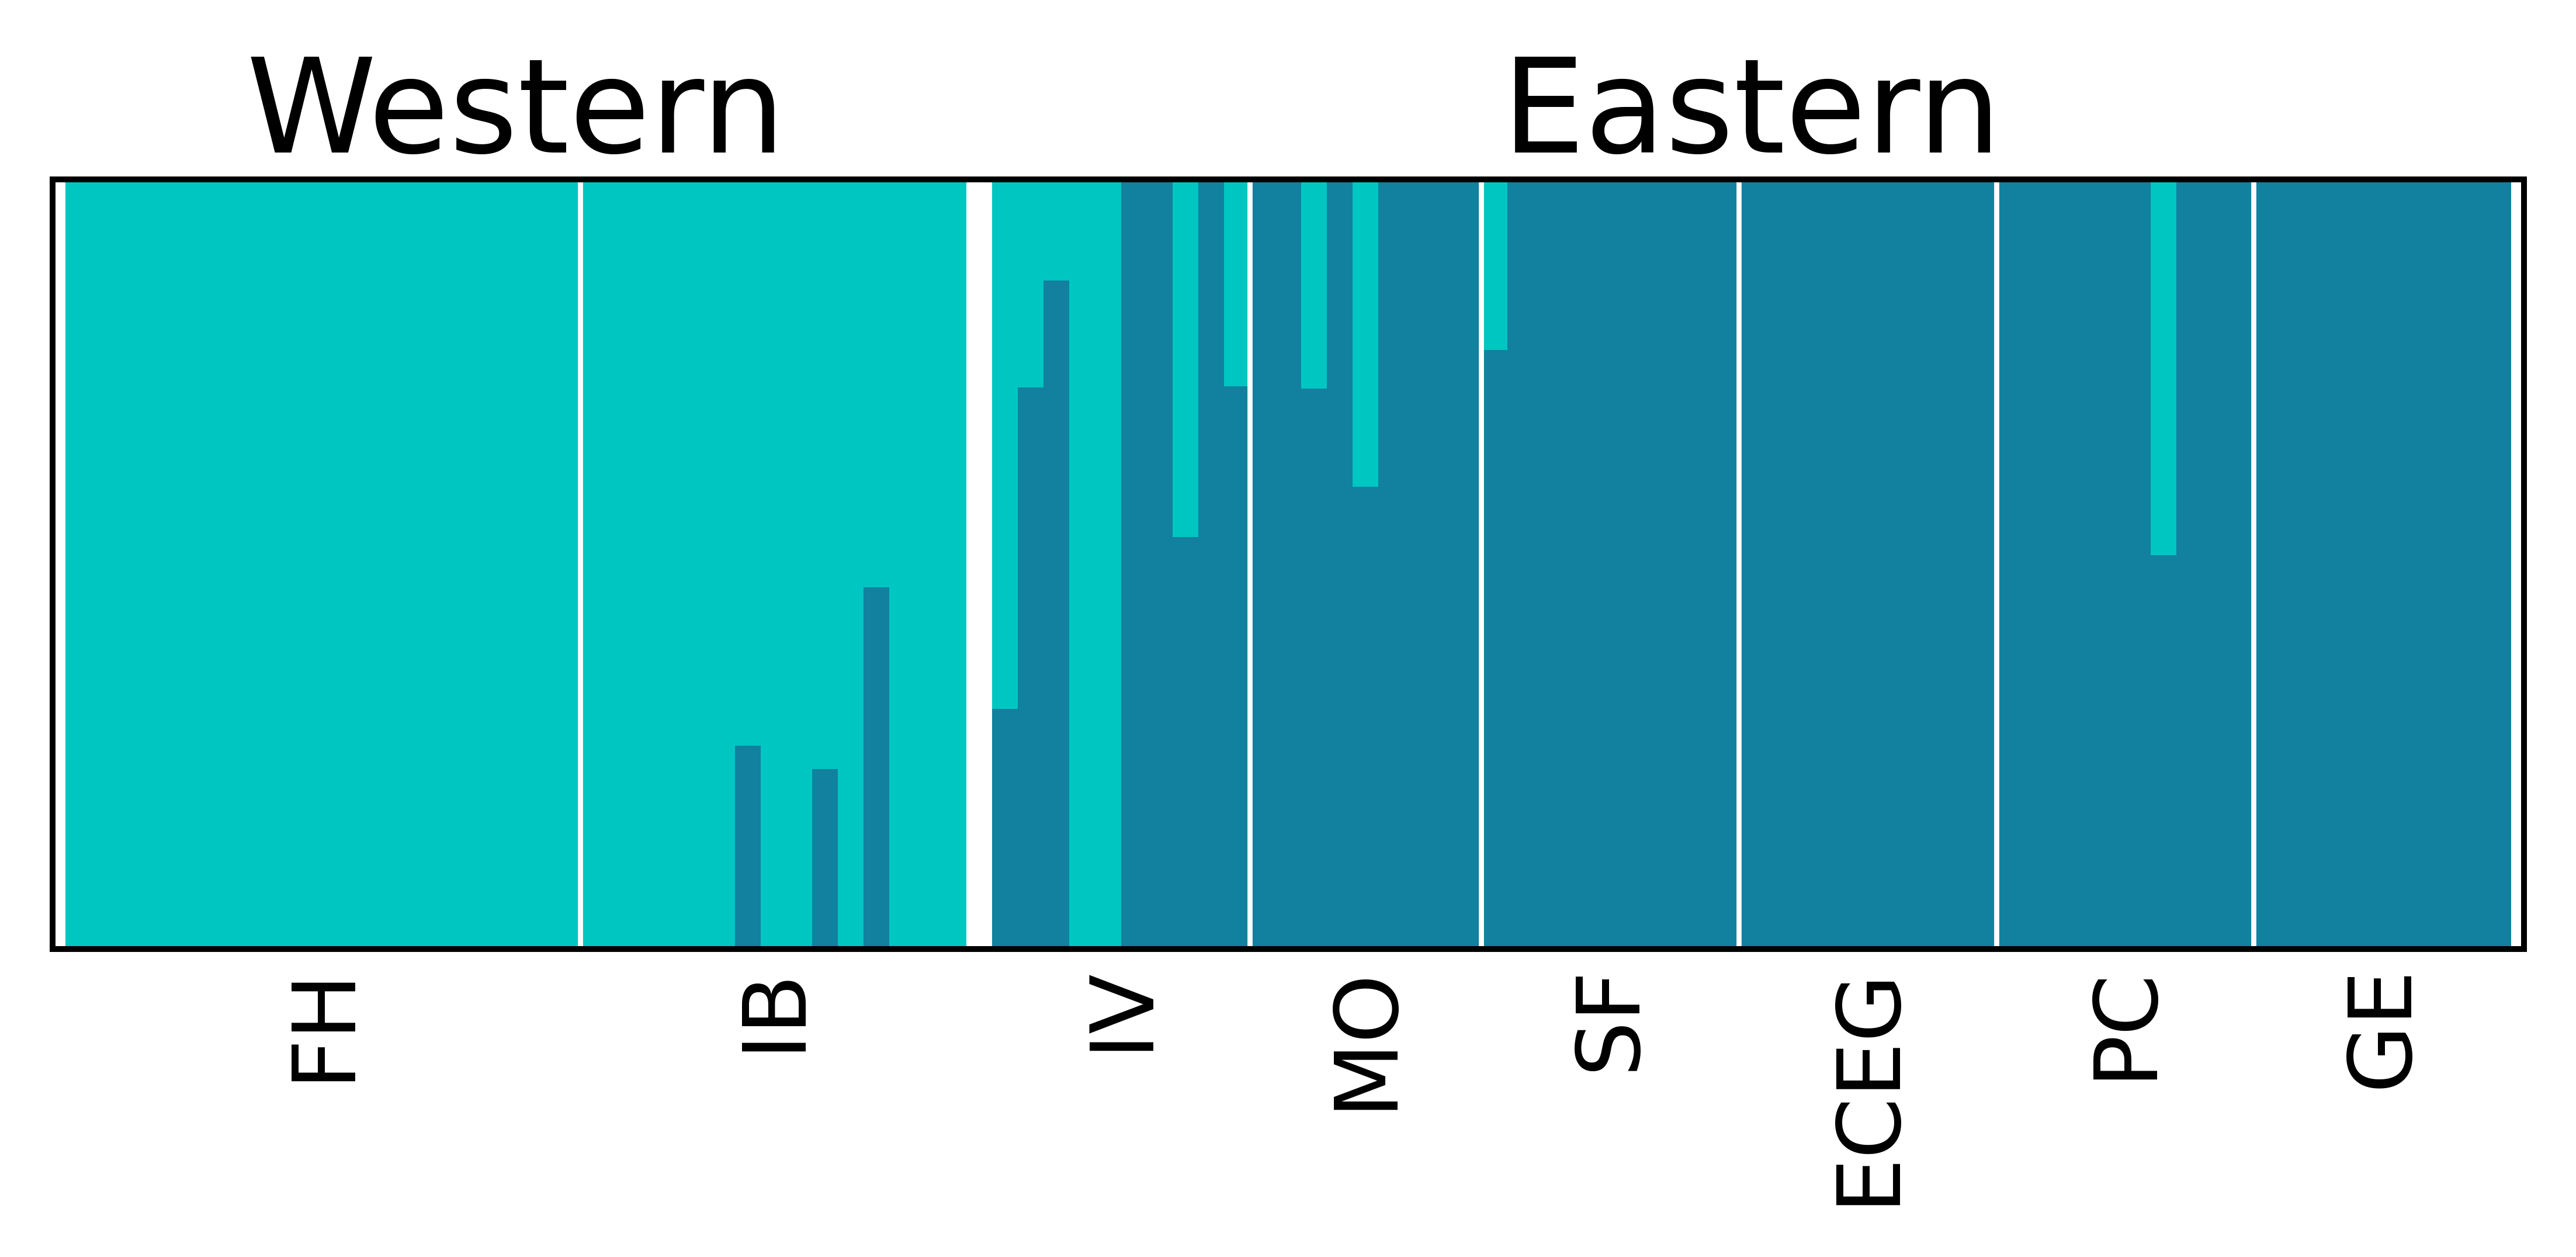

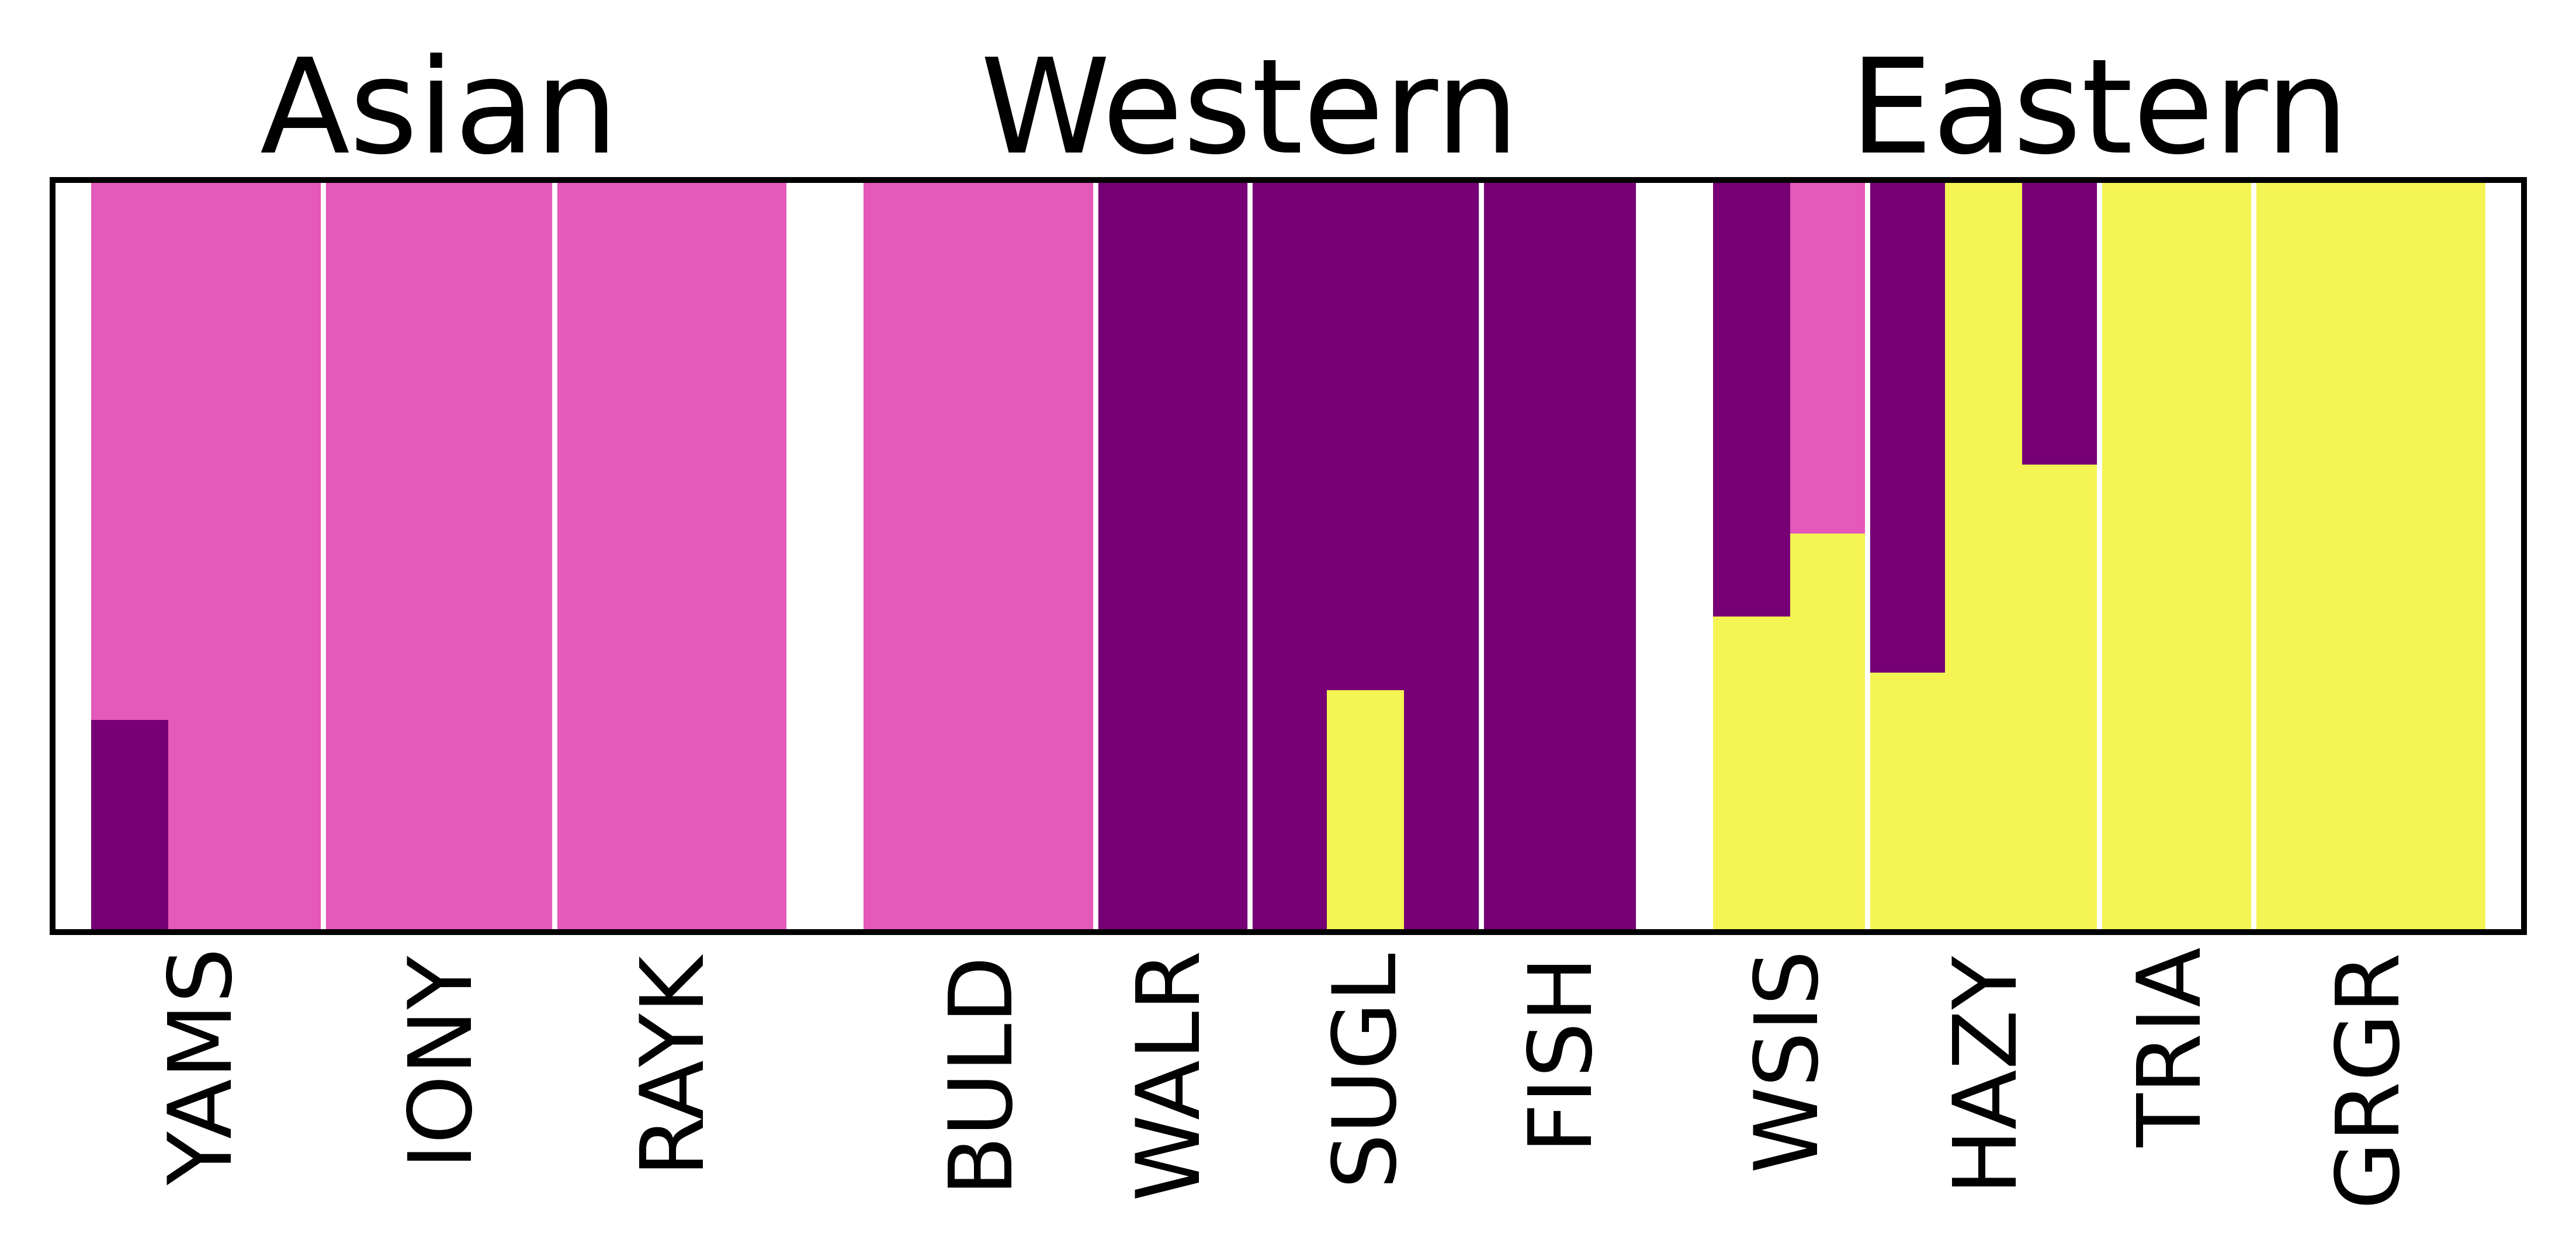

In [ ]:
# chr9
get_main_admixture(species="GSL", chr="CM019810.2", k=2)
get_main_admixture(species="SSL", chr="CM019810.2", k=3)

CM019819.2 GSL 2 Stock_K2
CM019819.2 SSL 3 Stock_K3


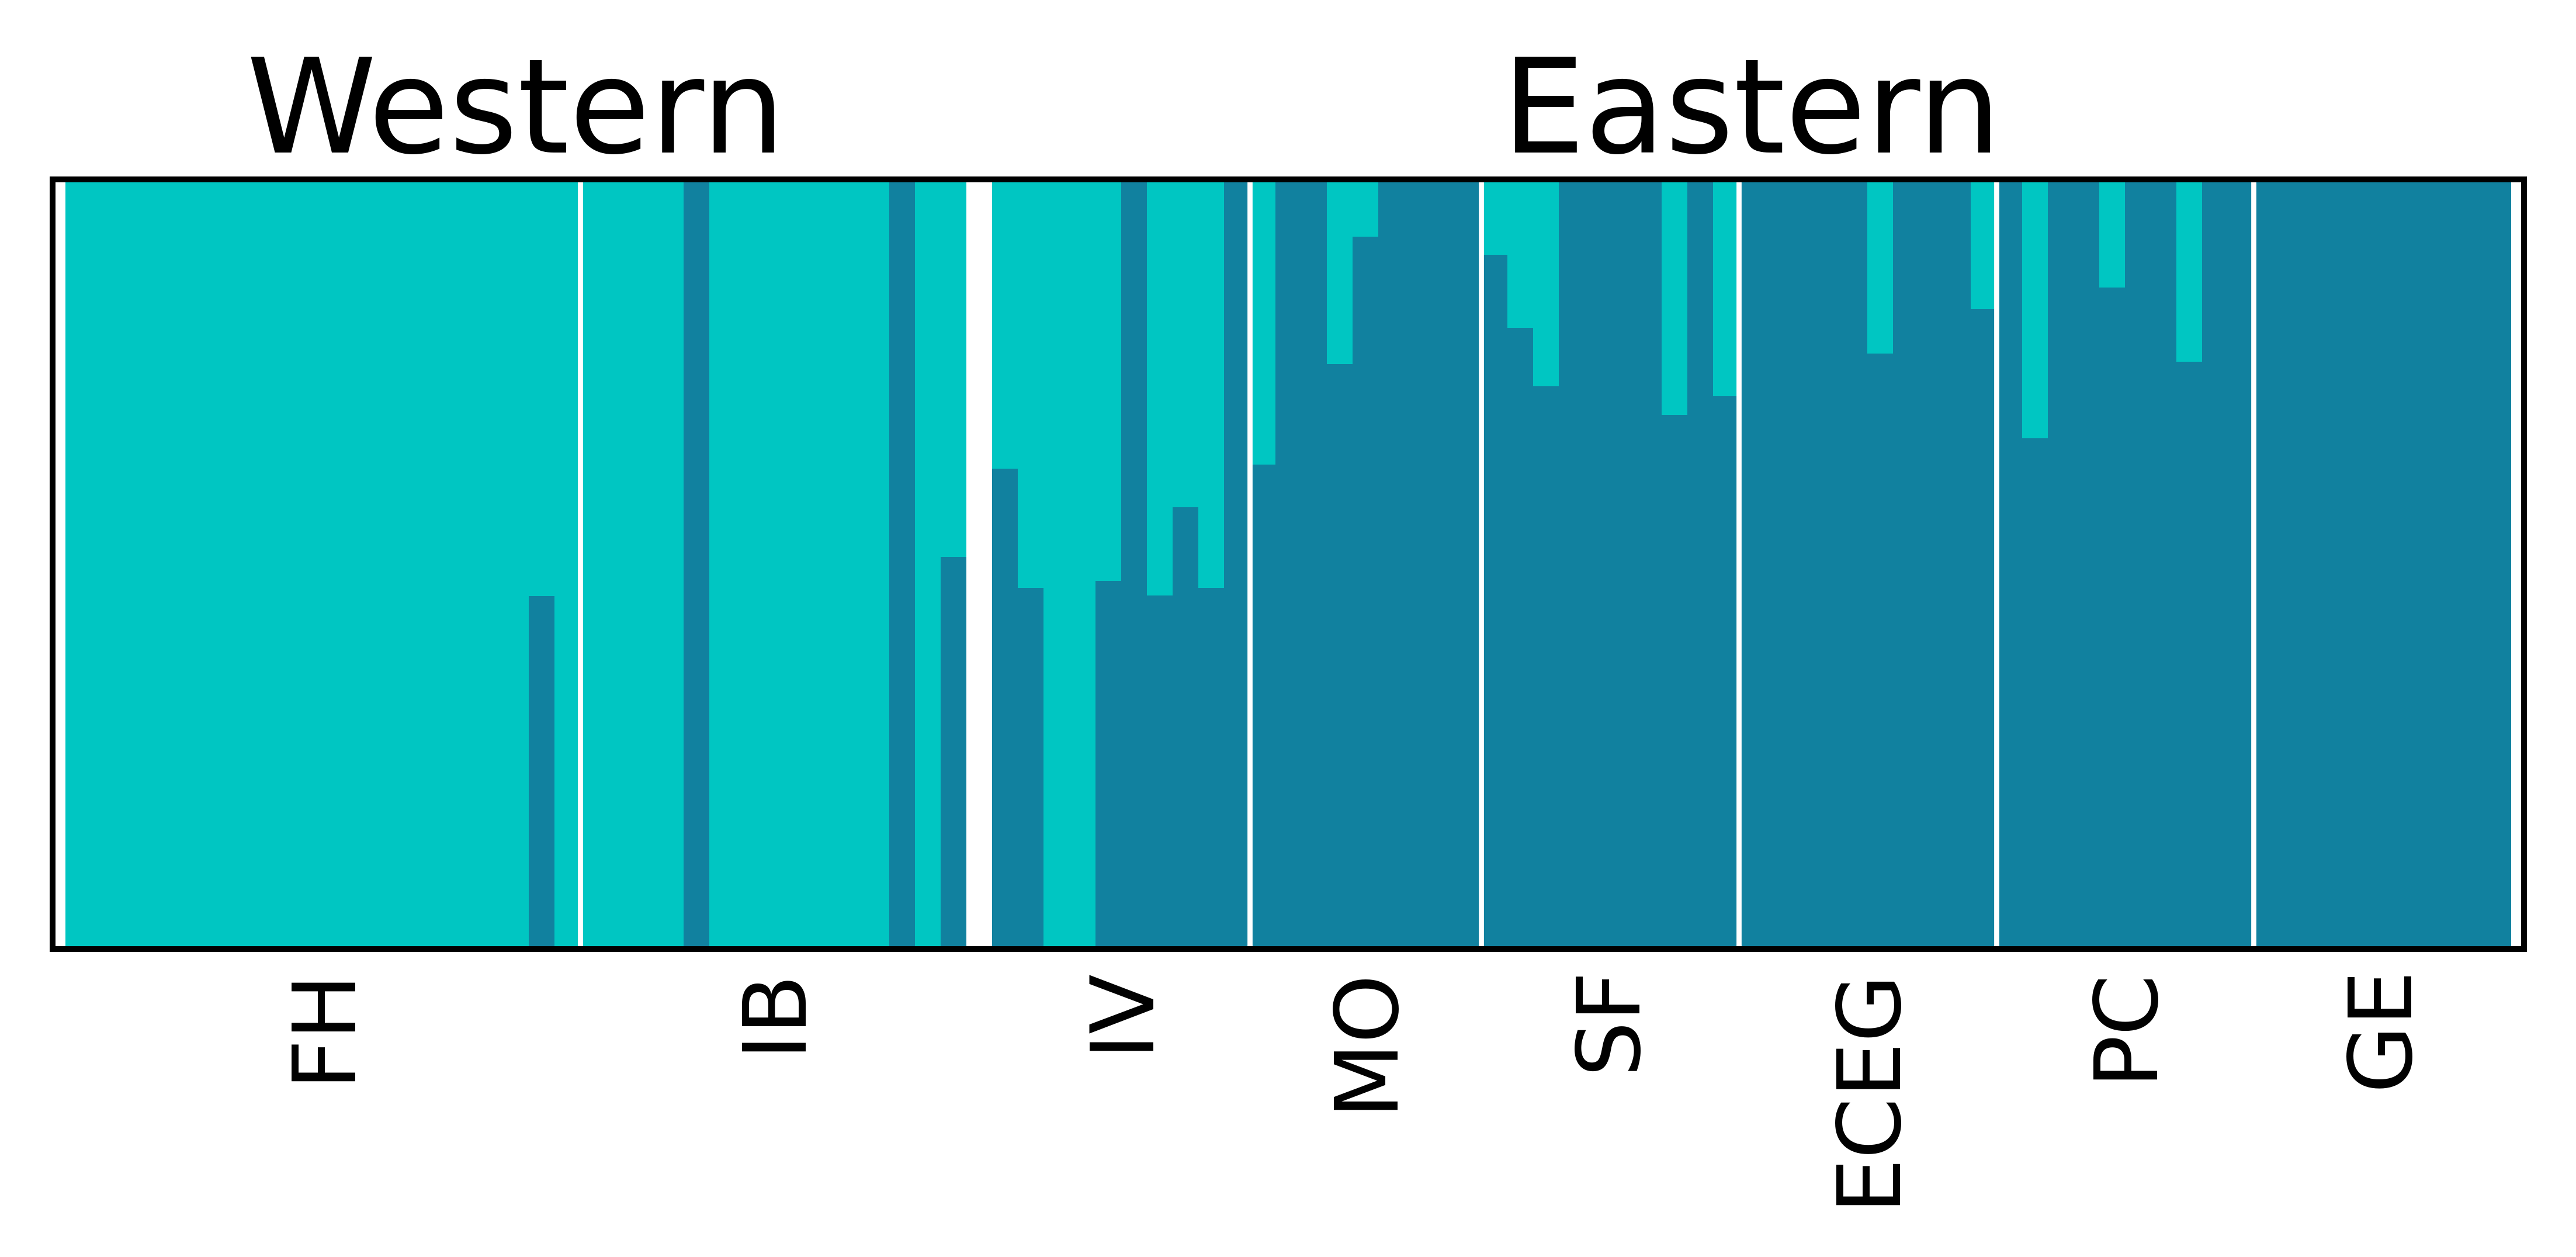

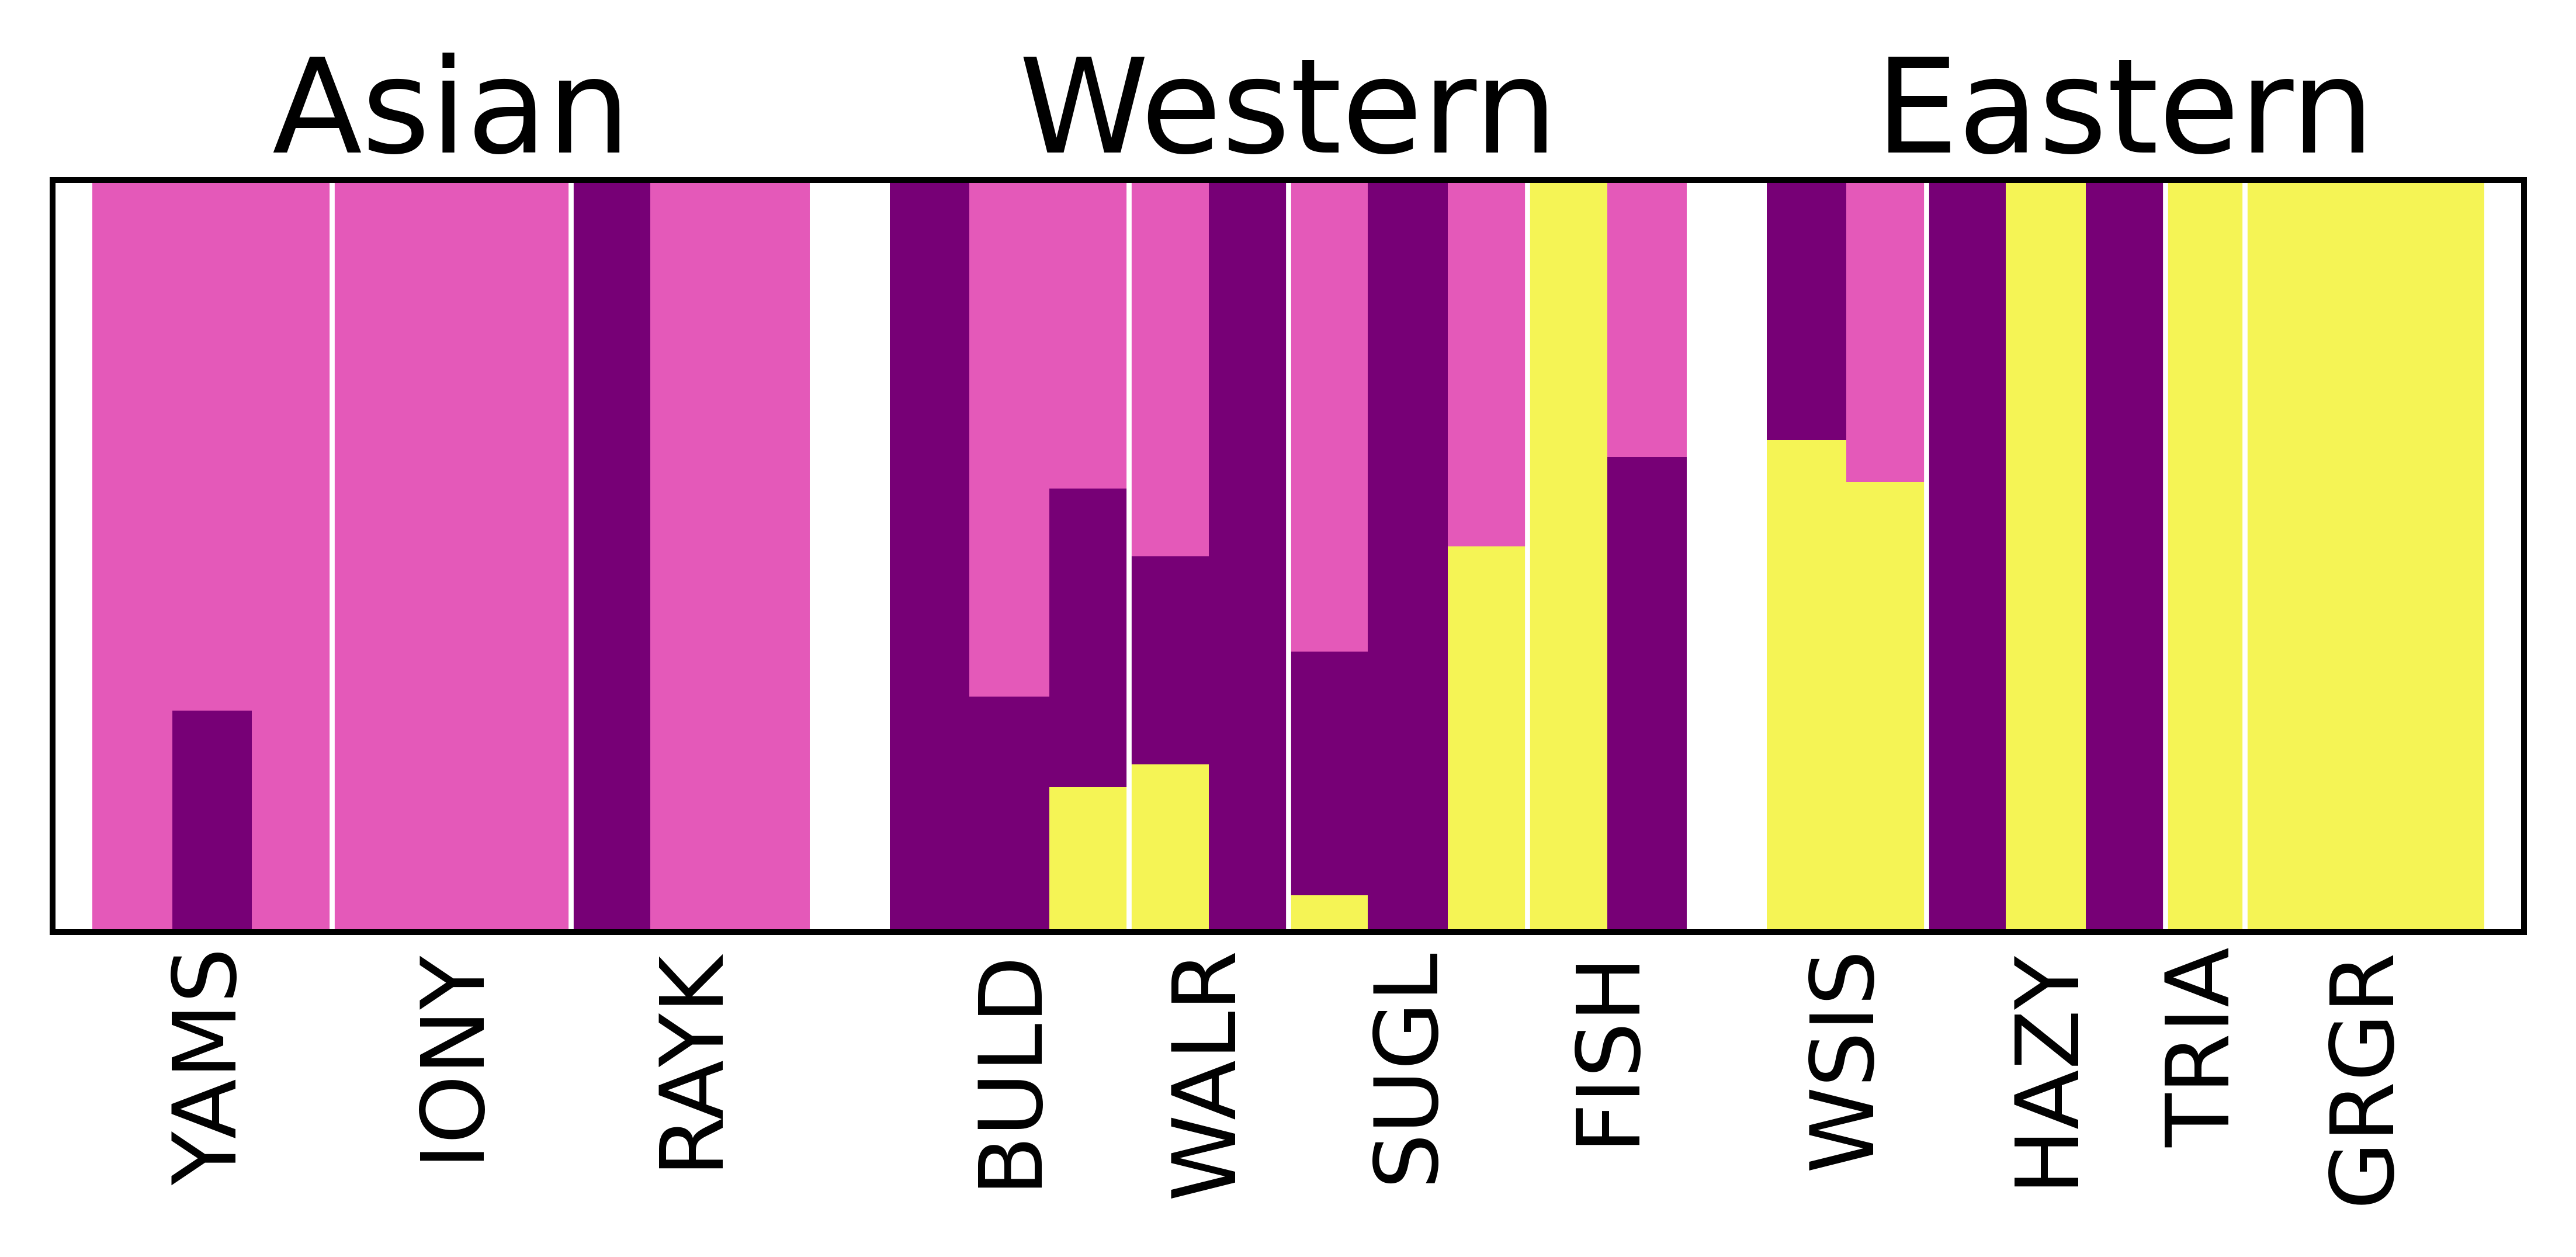

In [63]:
# X
get_main_admixture(species="GSL", chr="CM019819.2", k=2)
get_main_admixture(species="SSL", chr="CM019819.2", k=3)

## SUPPLEMENTARY

CM019810.2 GSL 3 Stock_K3
CM019810.2 SSL 2 Stock_K2


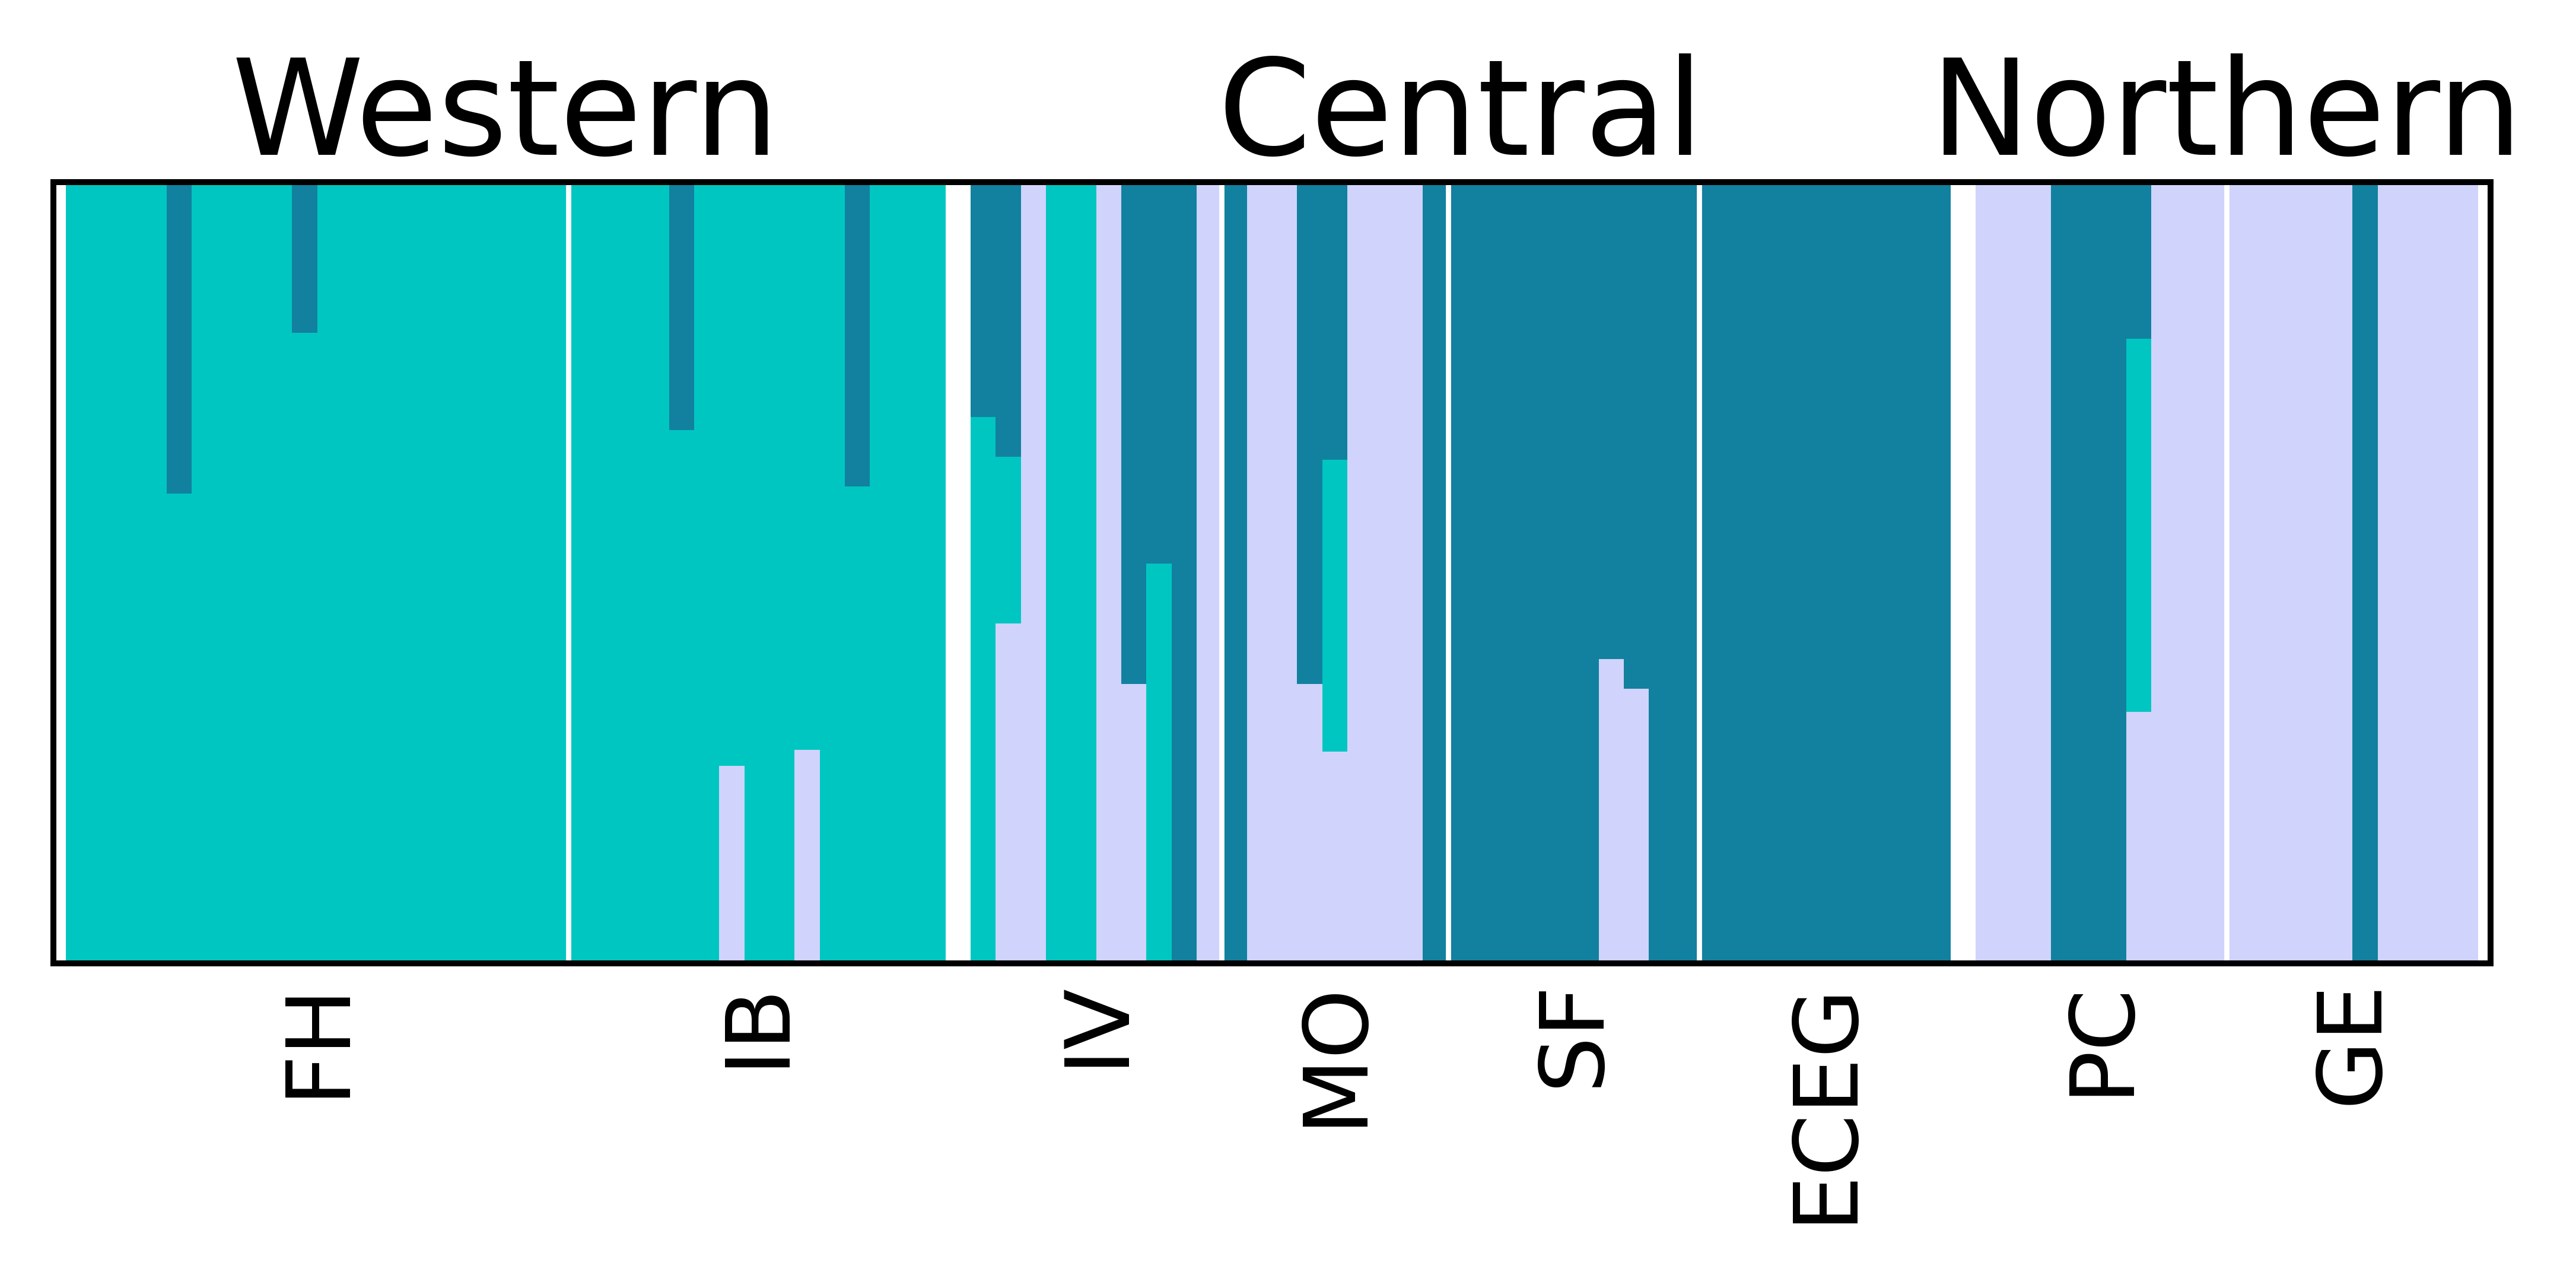

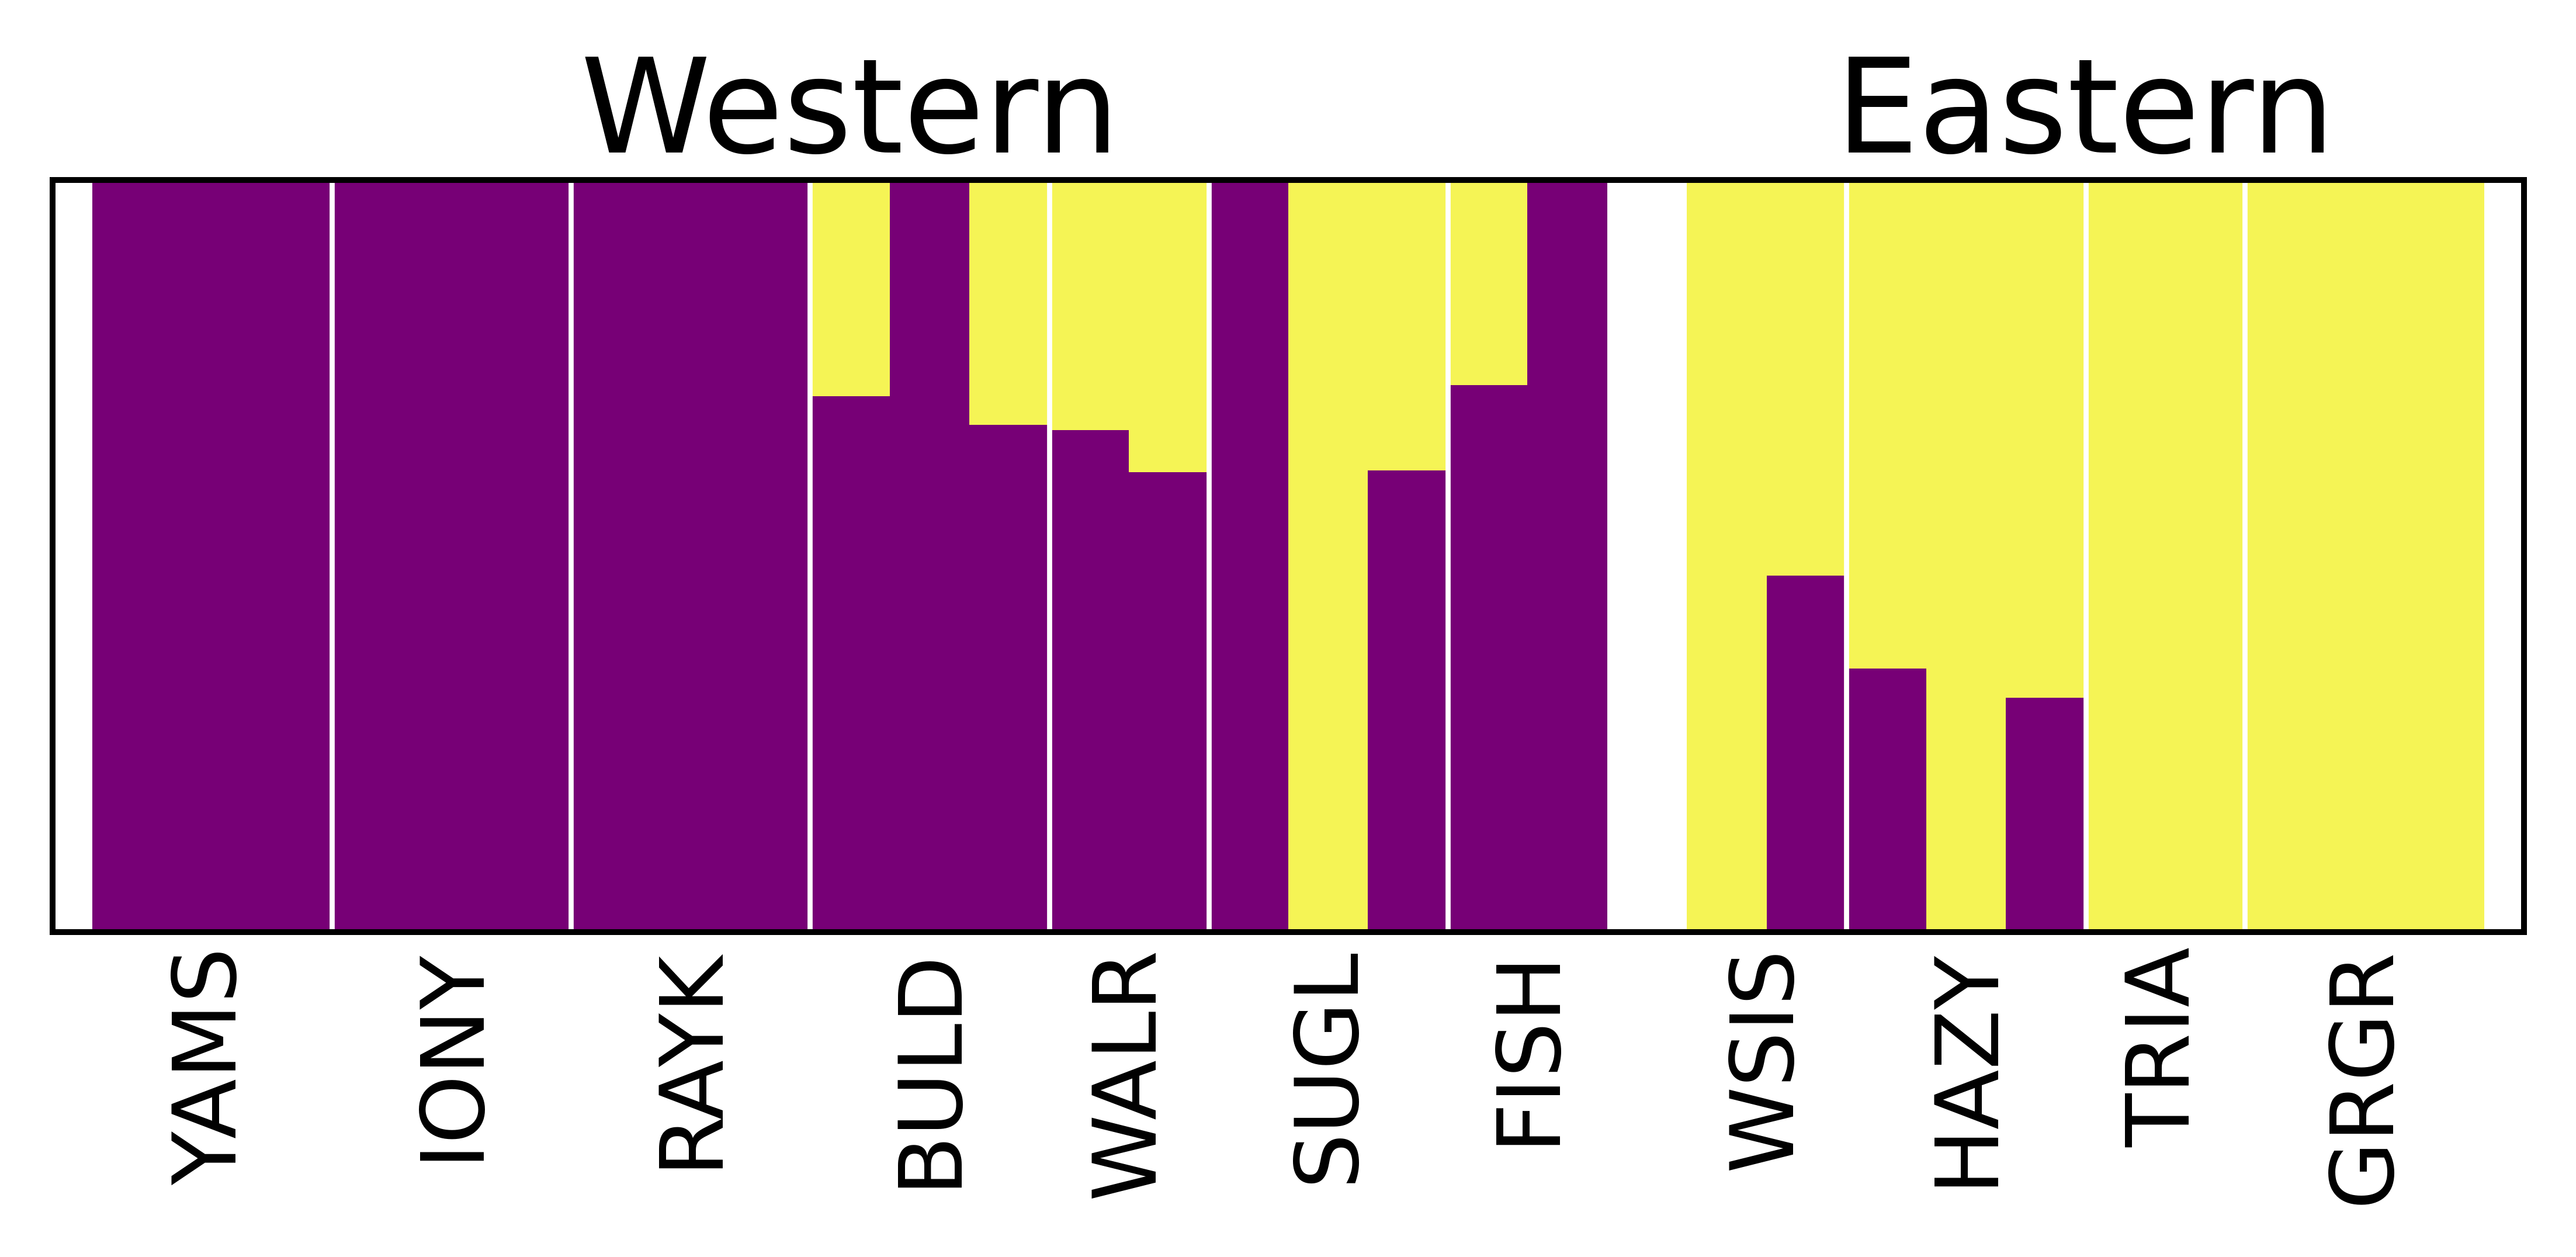

In [ ]:
# chr9
get_main_admixture(species="GSL", chr="CM019810.2", k=3)
get_main_admixture(species="SSL", chr="CM019810.2", k=2)

CM019819.2 GSL 3 Stock_K3
CM019819.2 SSL 2 Stock_K2


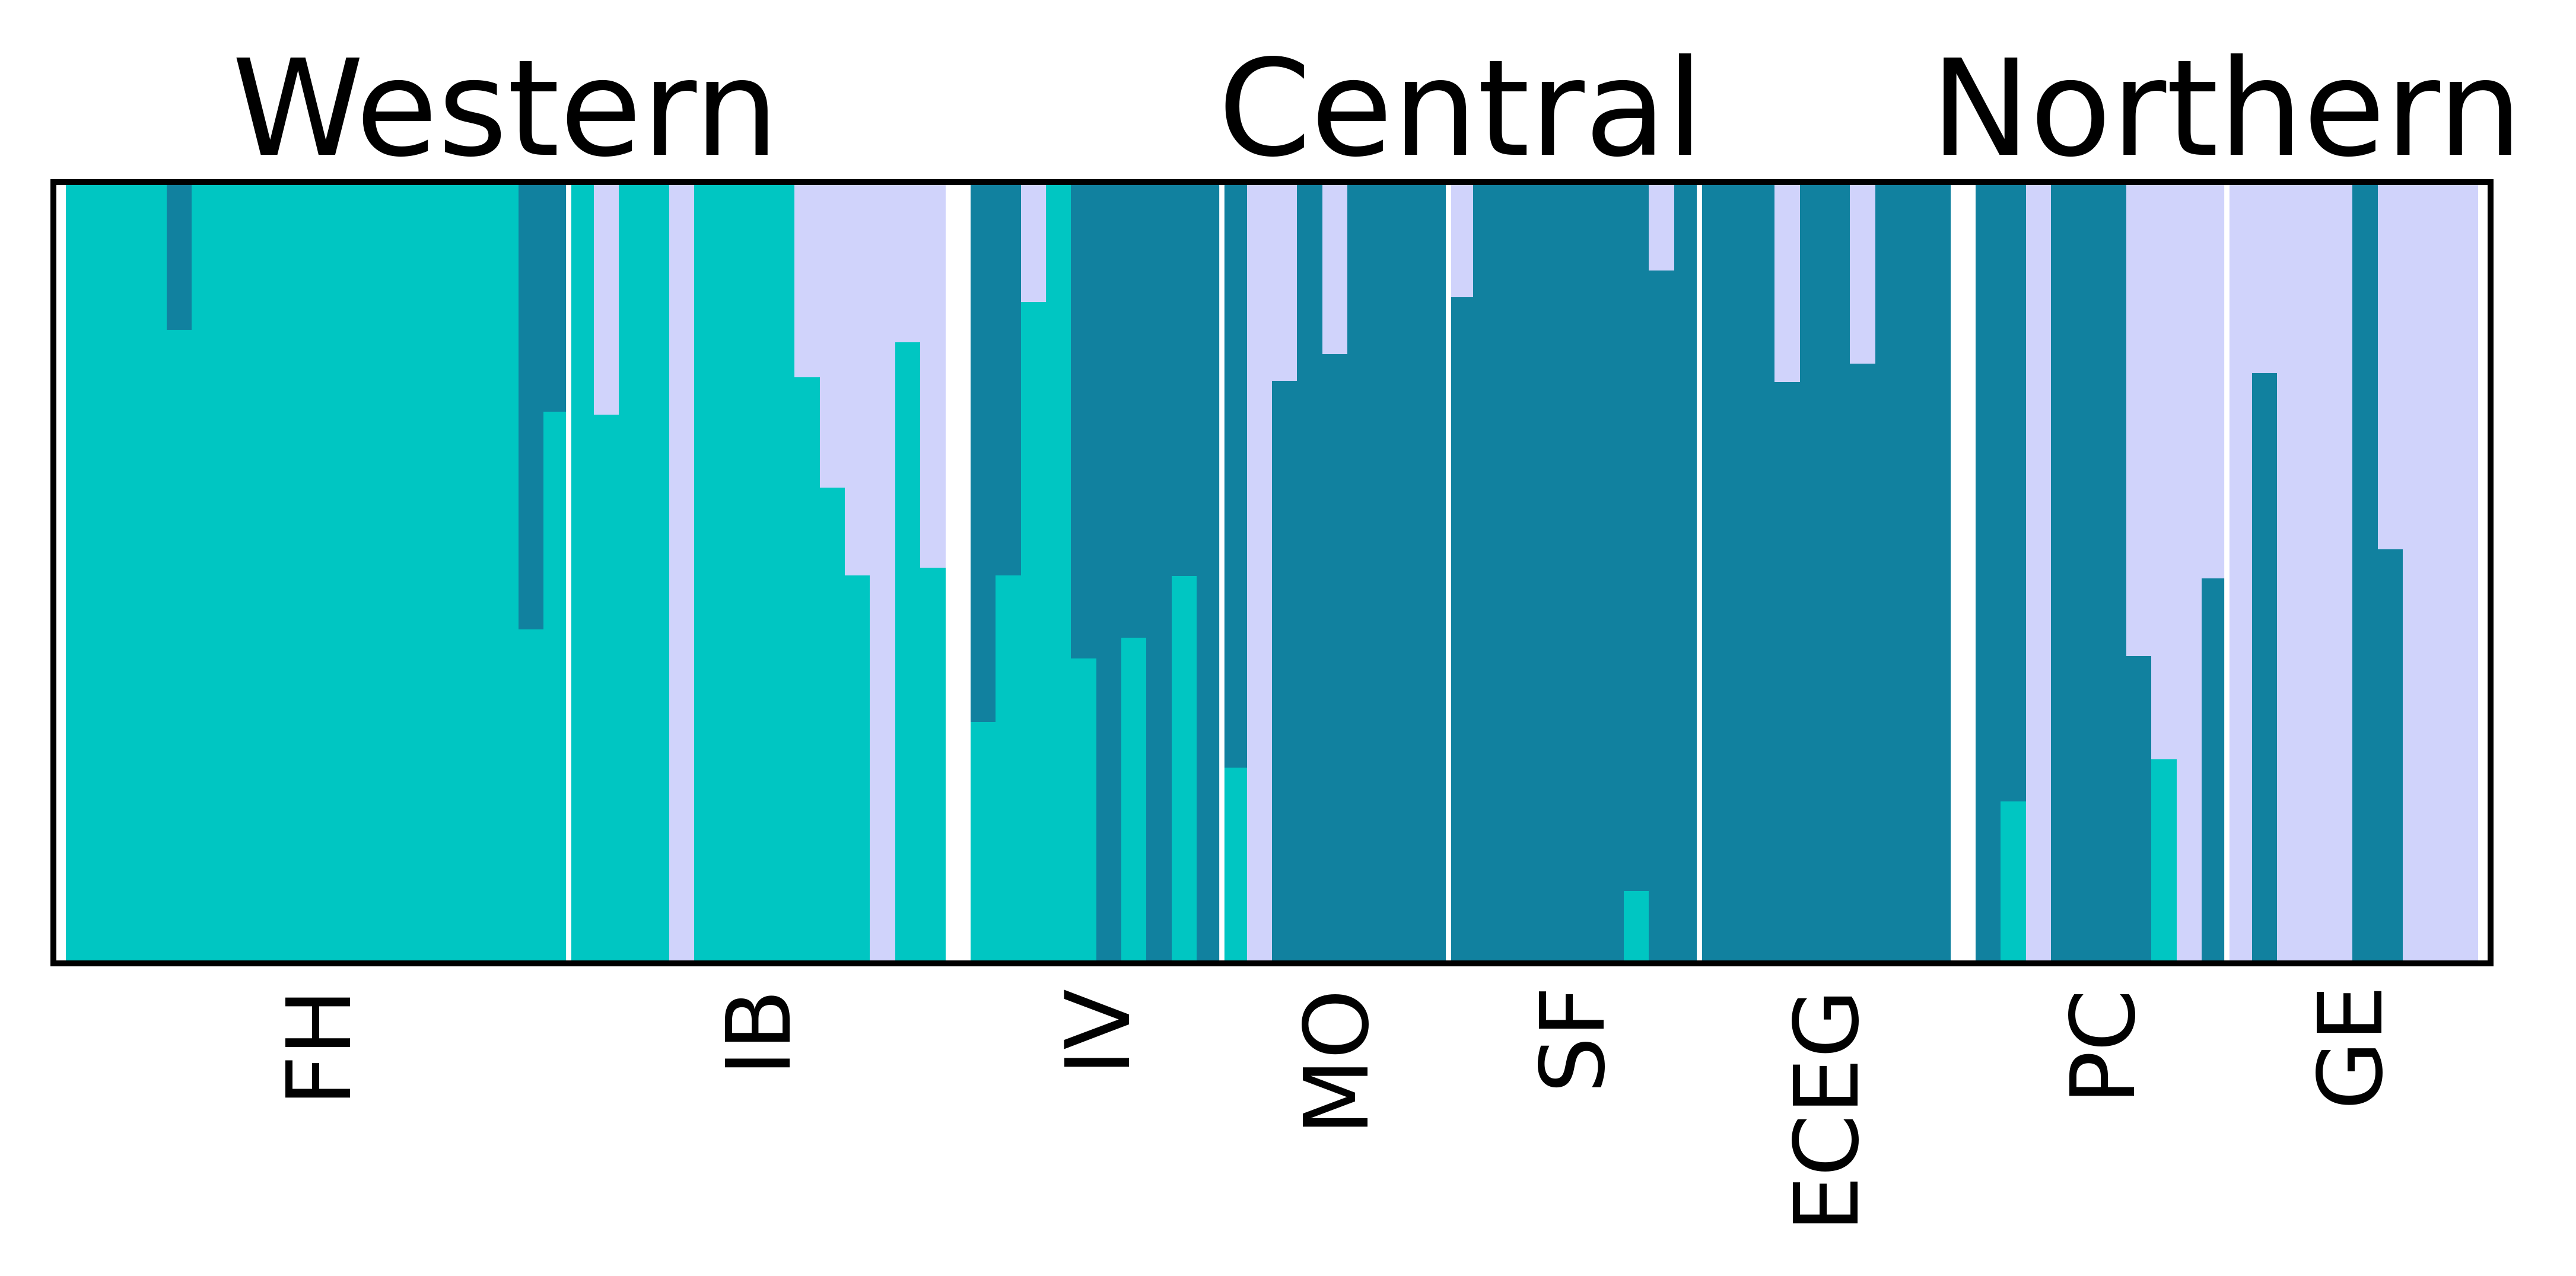

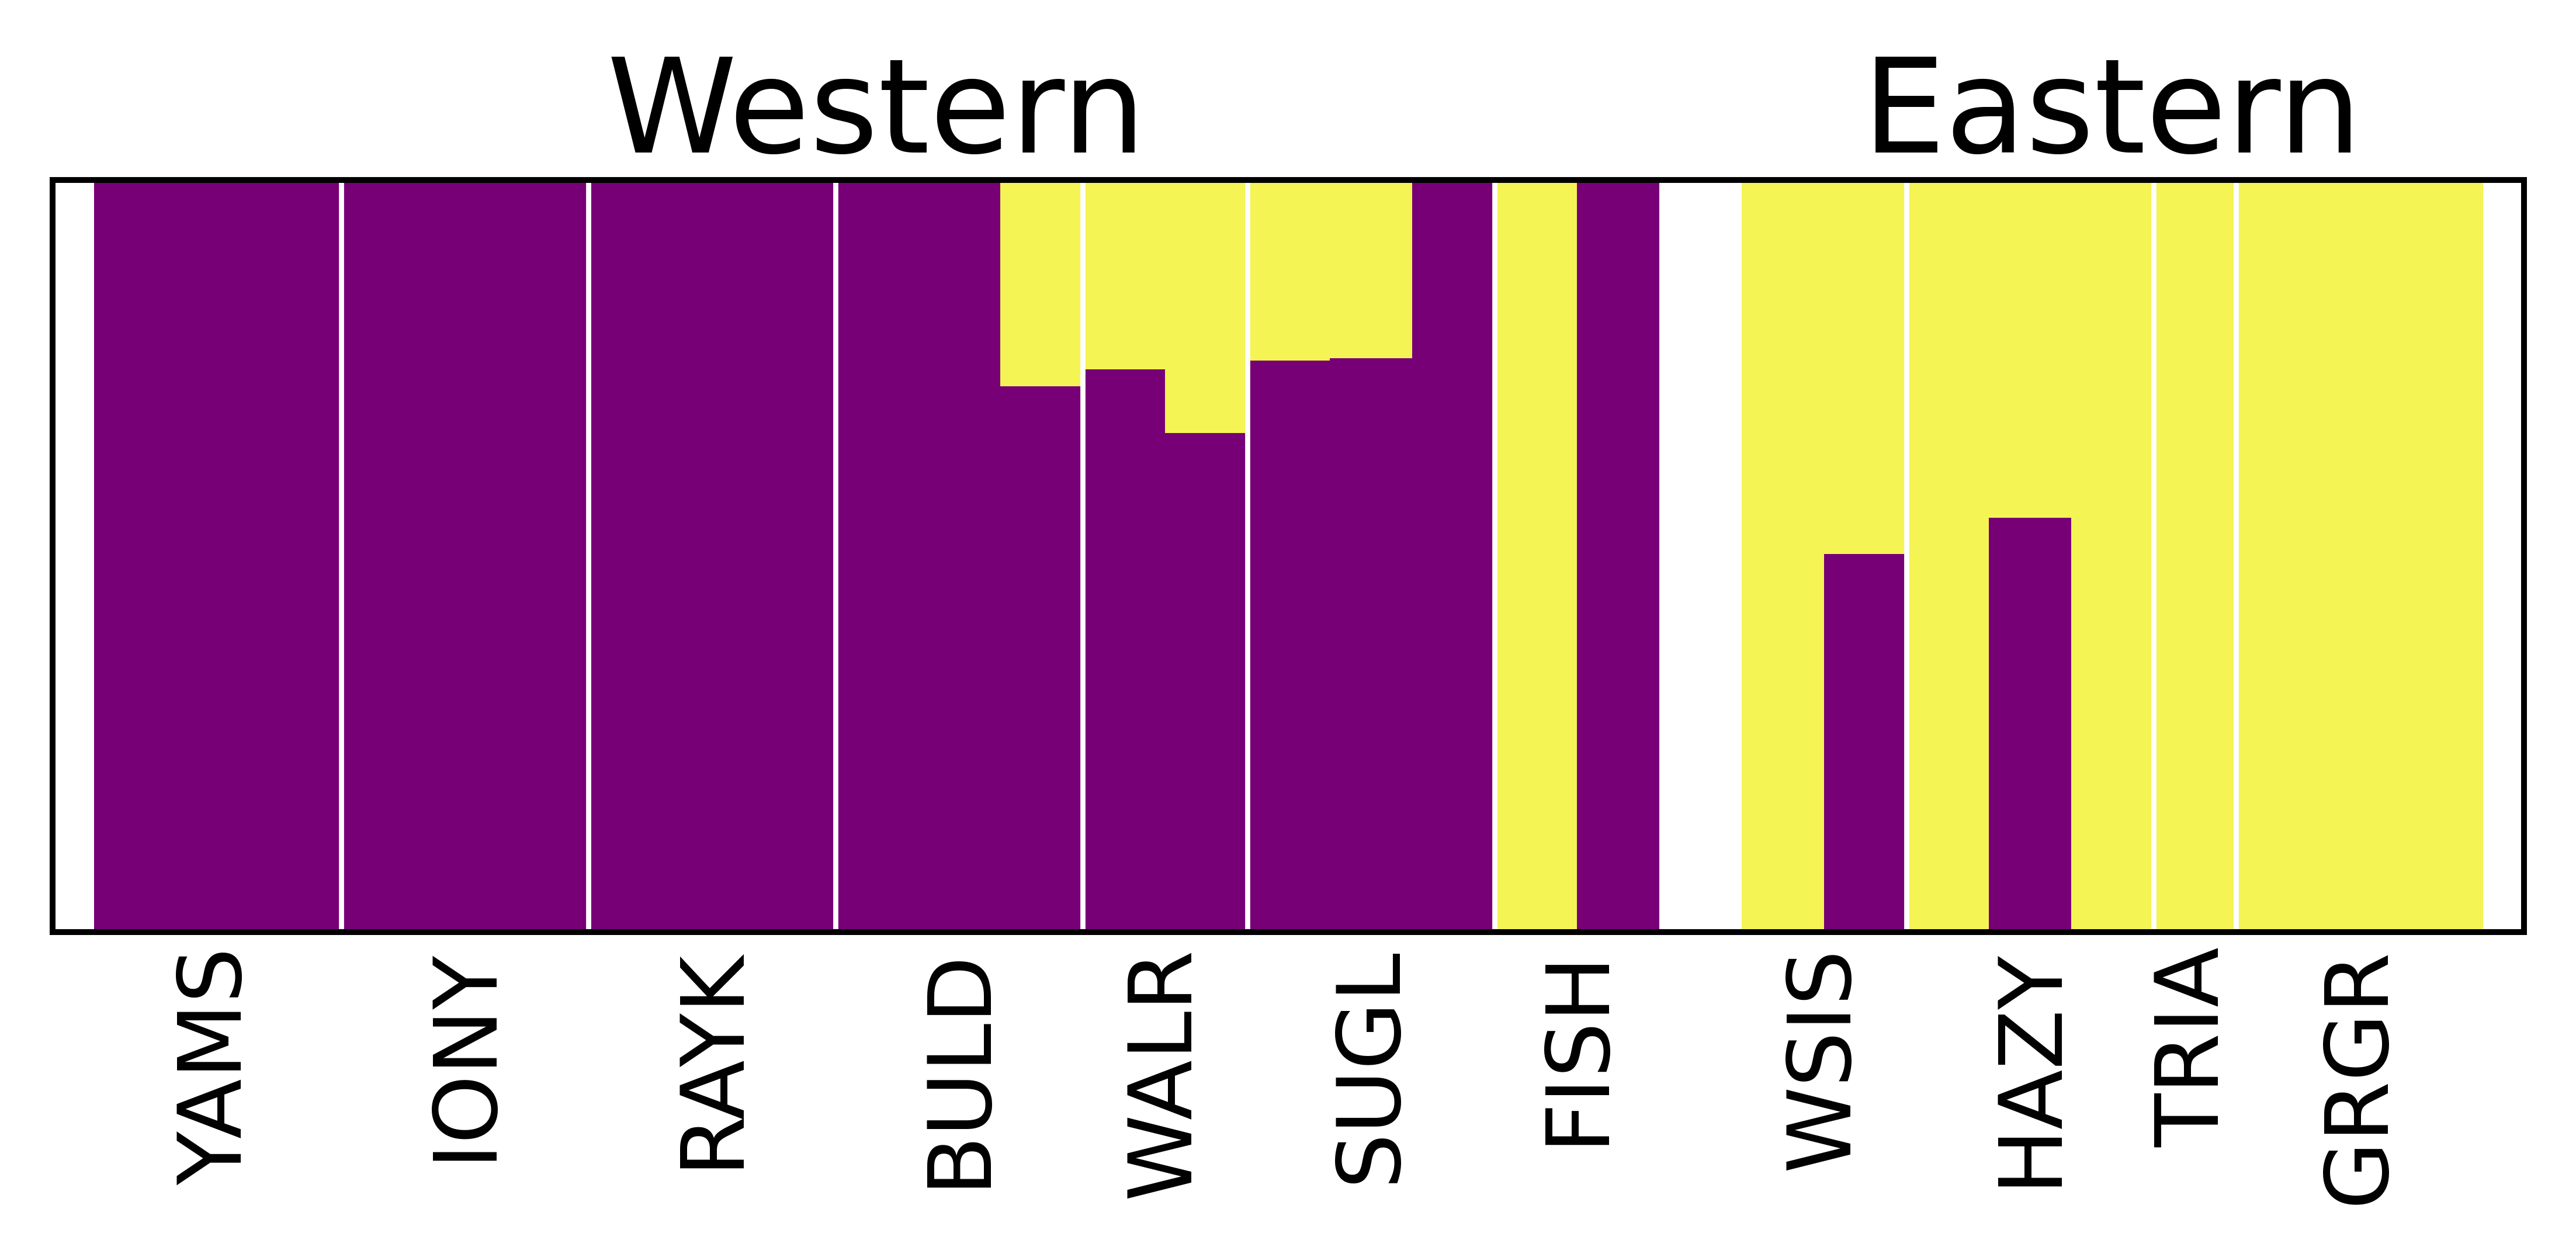

In [62]:
# X
get_main_admixture(species="GSL", chr="CM019819.2", k=3)
get_main_admixture(species="SSL", chr="CM019819.2", k=2)

# SUPPLEMENTARY TEXT

## baseline

### AUT

CM019810.2 GSL 2 Stock_K2
CM019810.2 SSL 3 Stock_K3


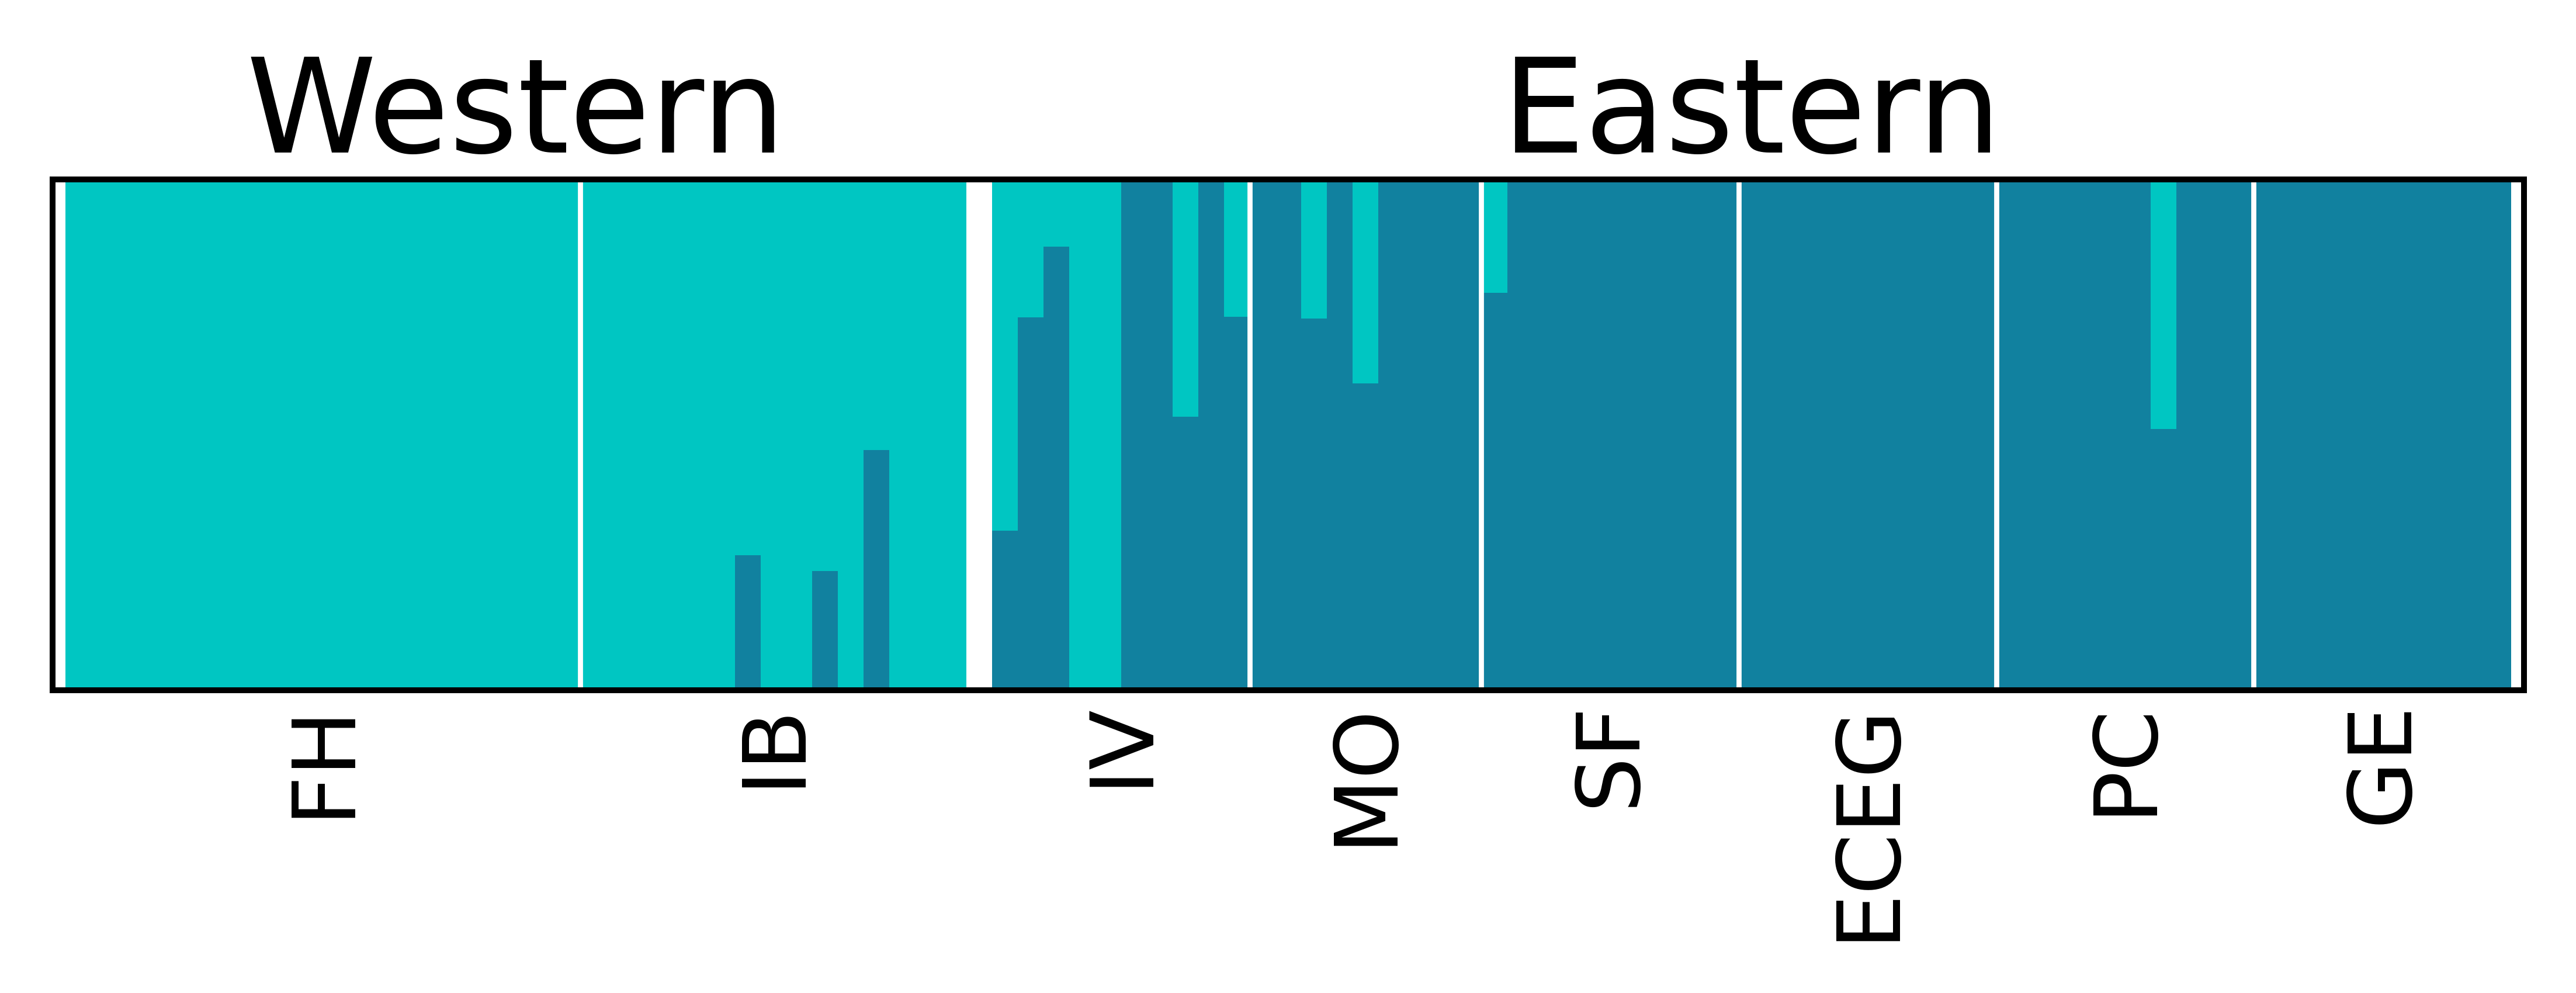

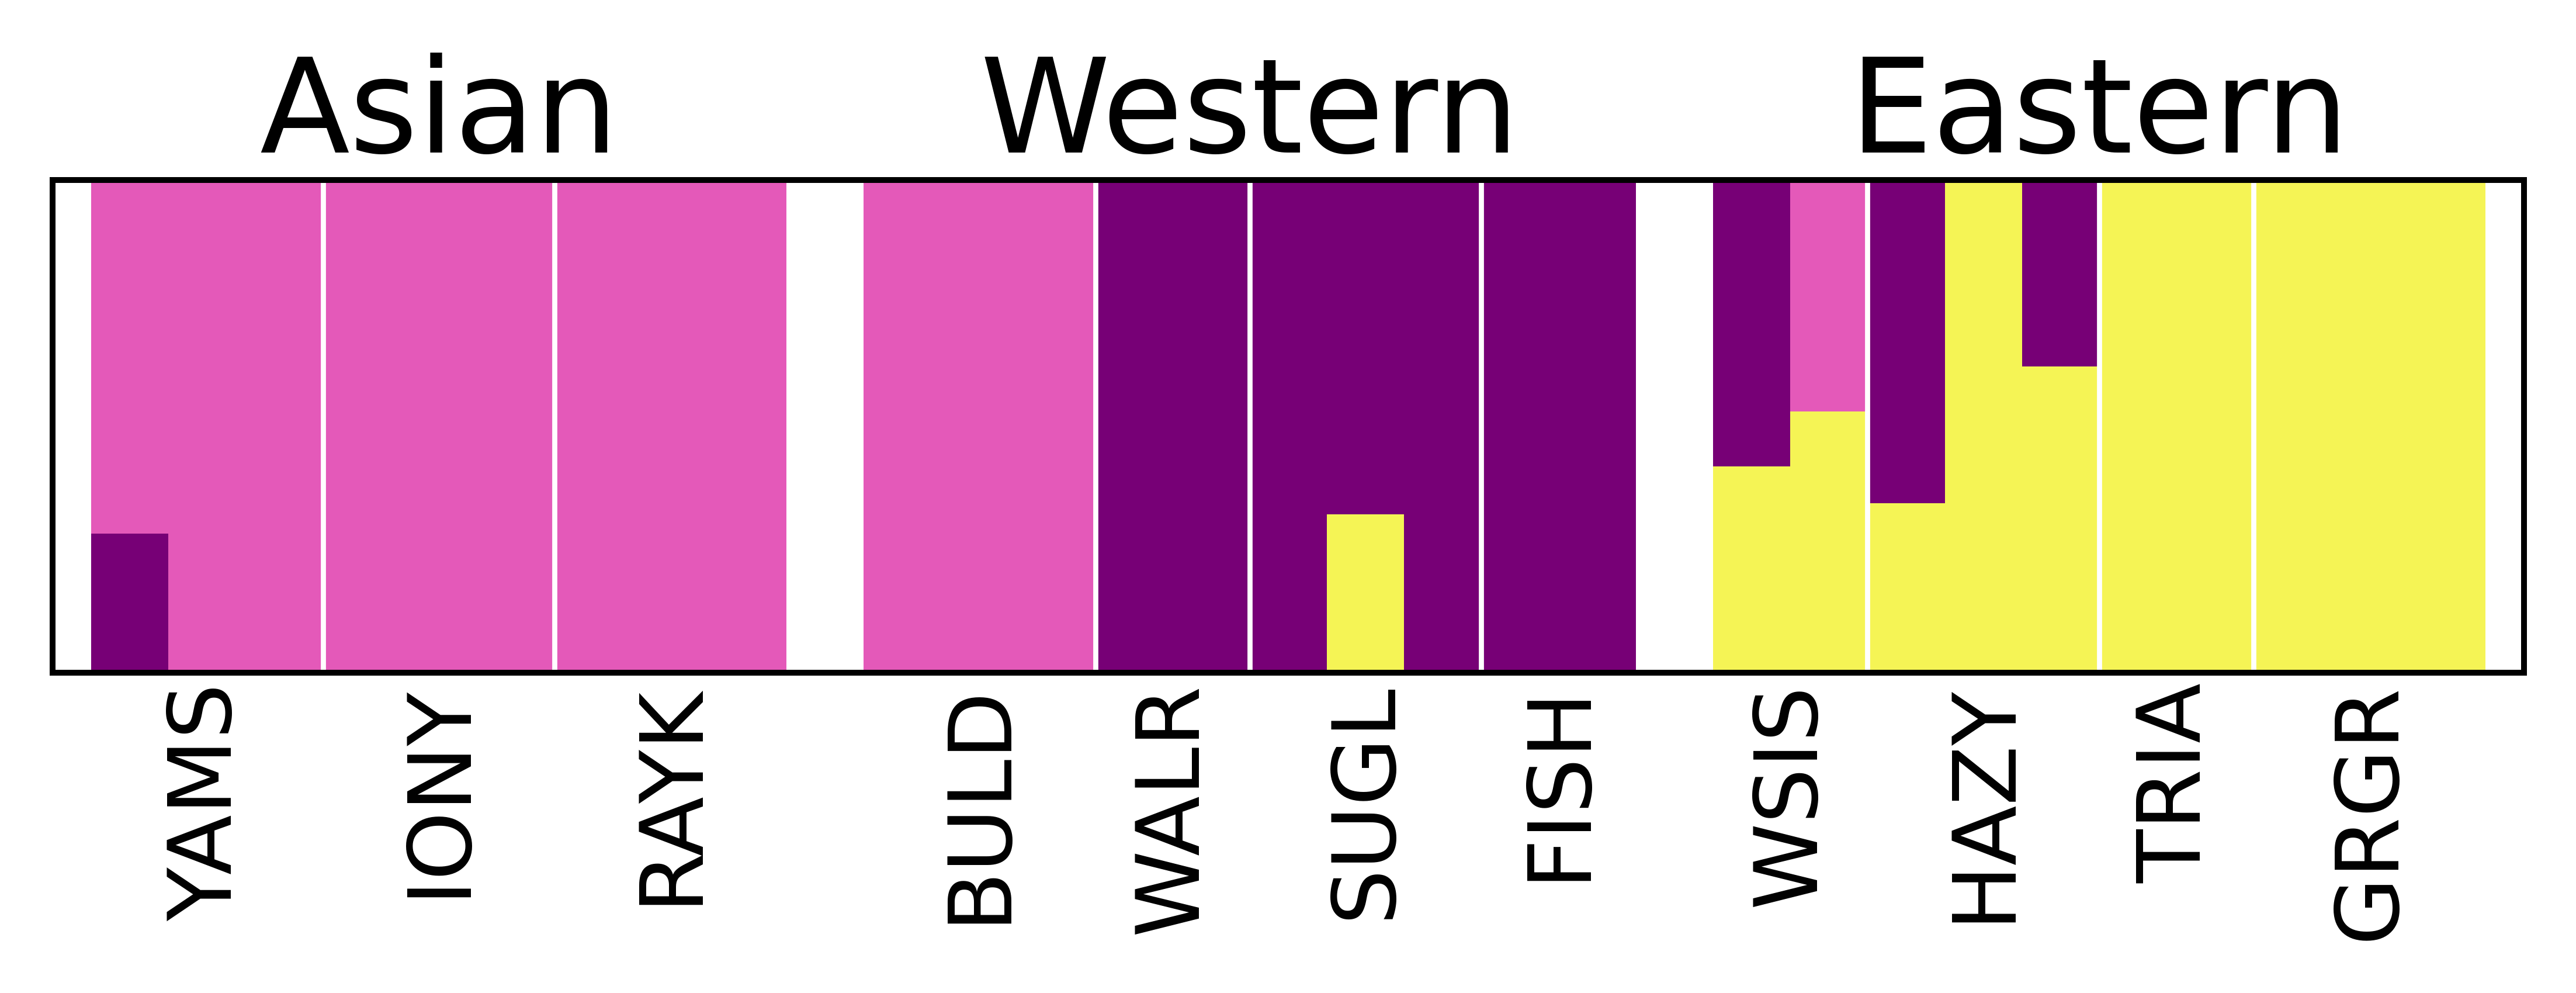

In [ ]:
# baseline chr9
get_main_admixture(species="GSL", chr="CM019810.2", k=2, figsize=(5, 2))
get_main_admixture(species="SSL", chr="CM019810.2", k=3, figsize=(5, 2))

### X

CM019819.2 GSL 2 Stock_K2
CM019819.2 SSL 3 Stock_K3


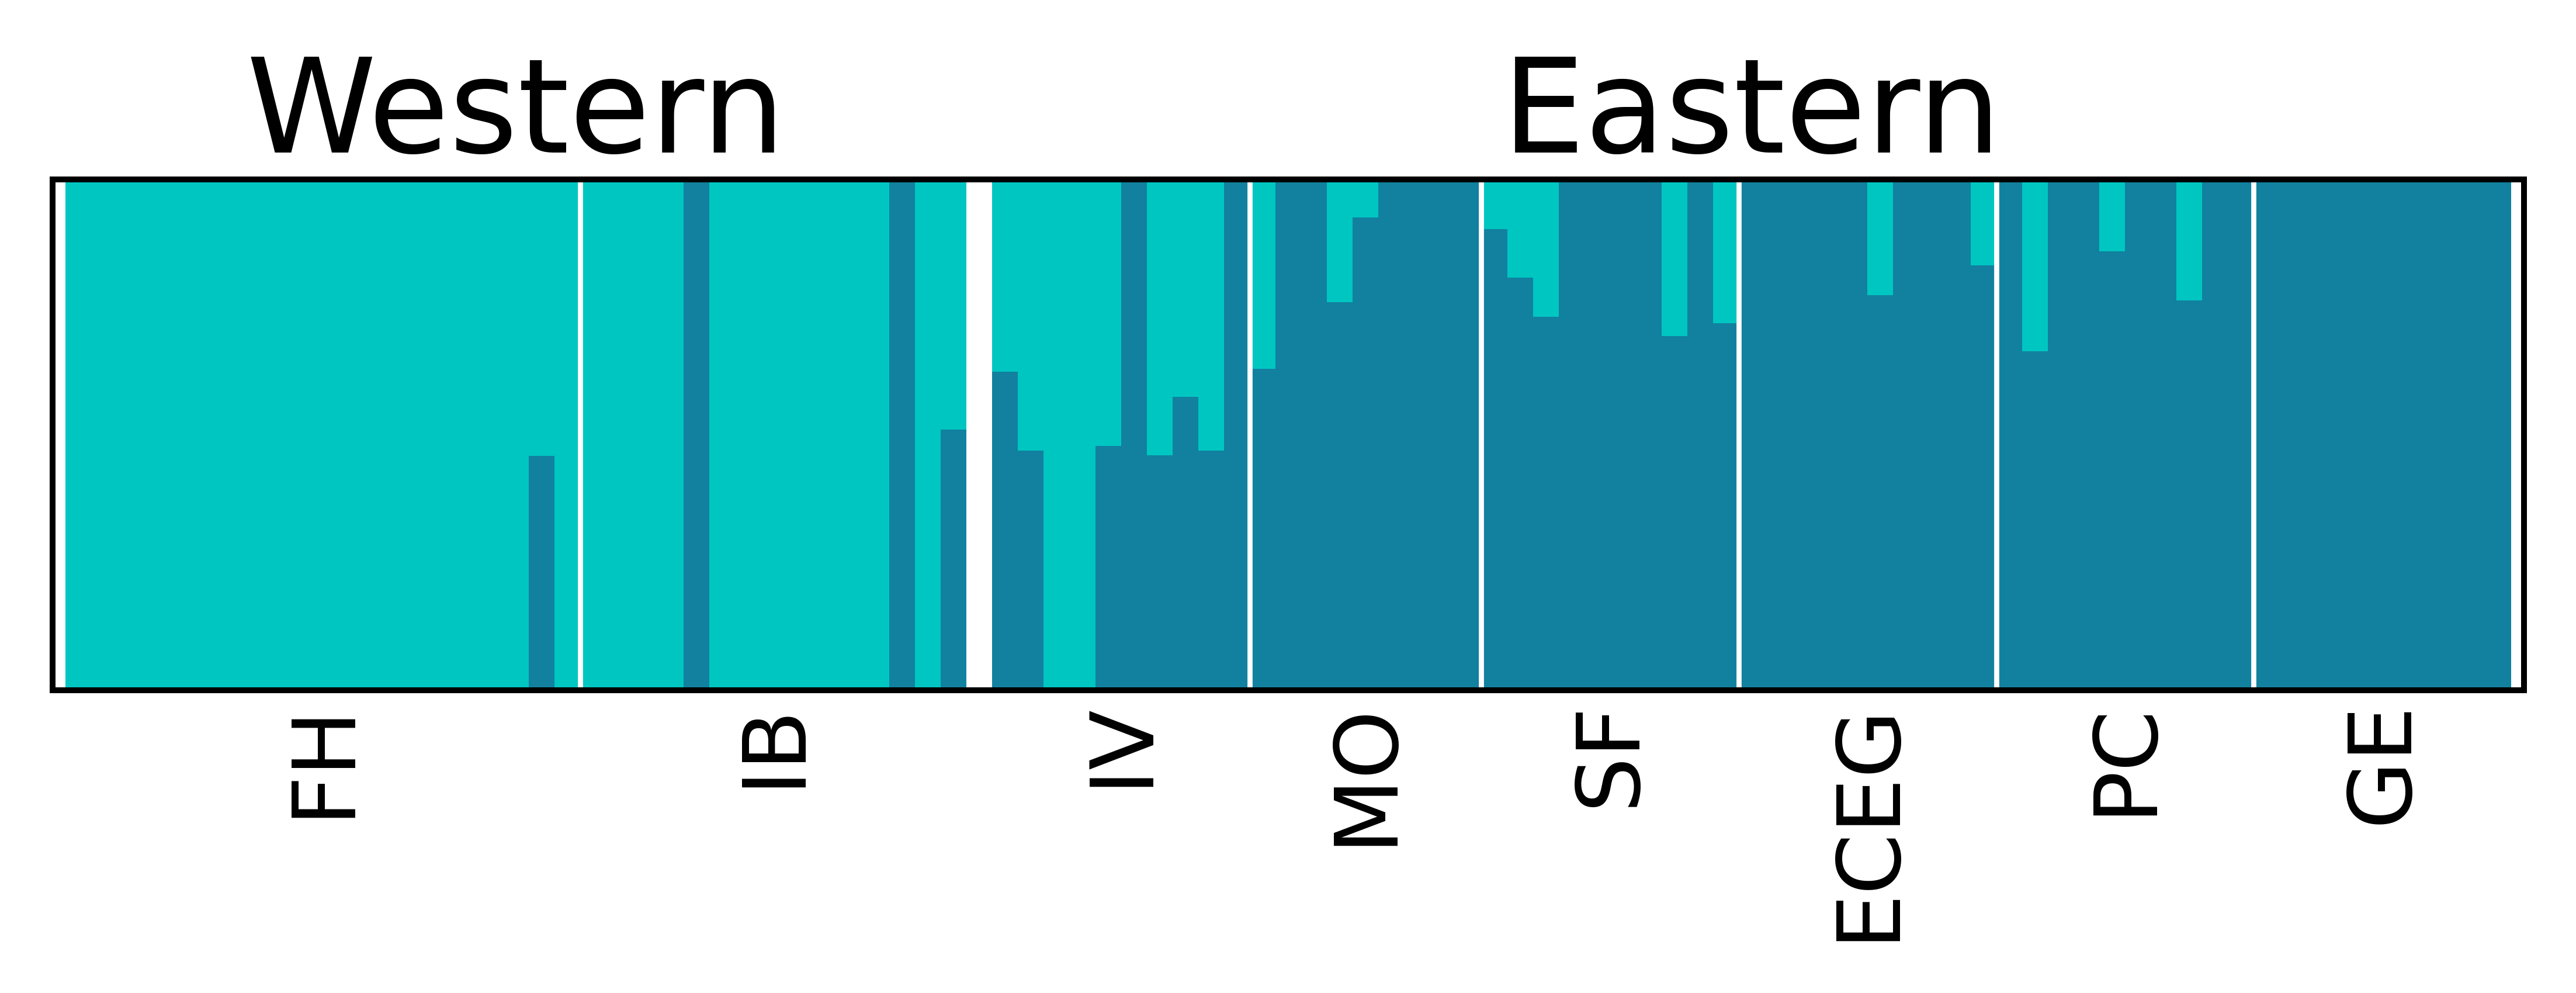

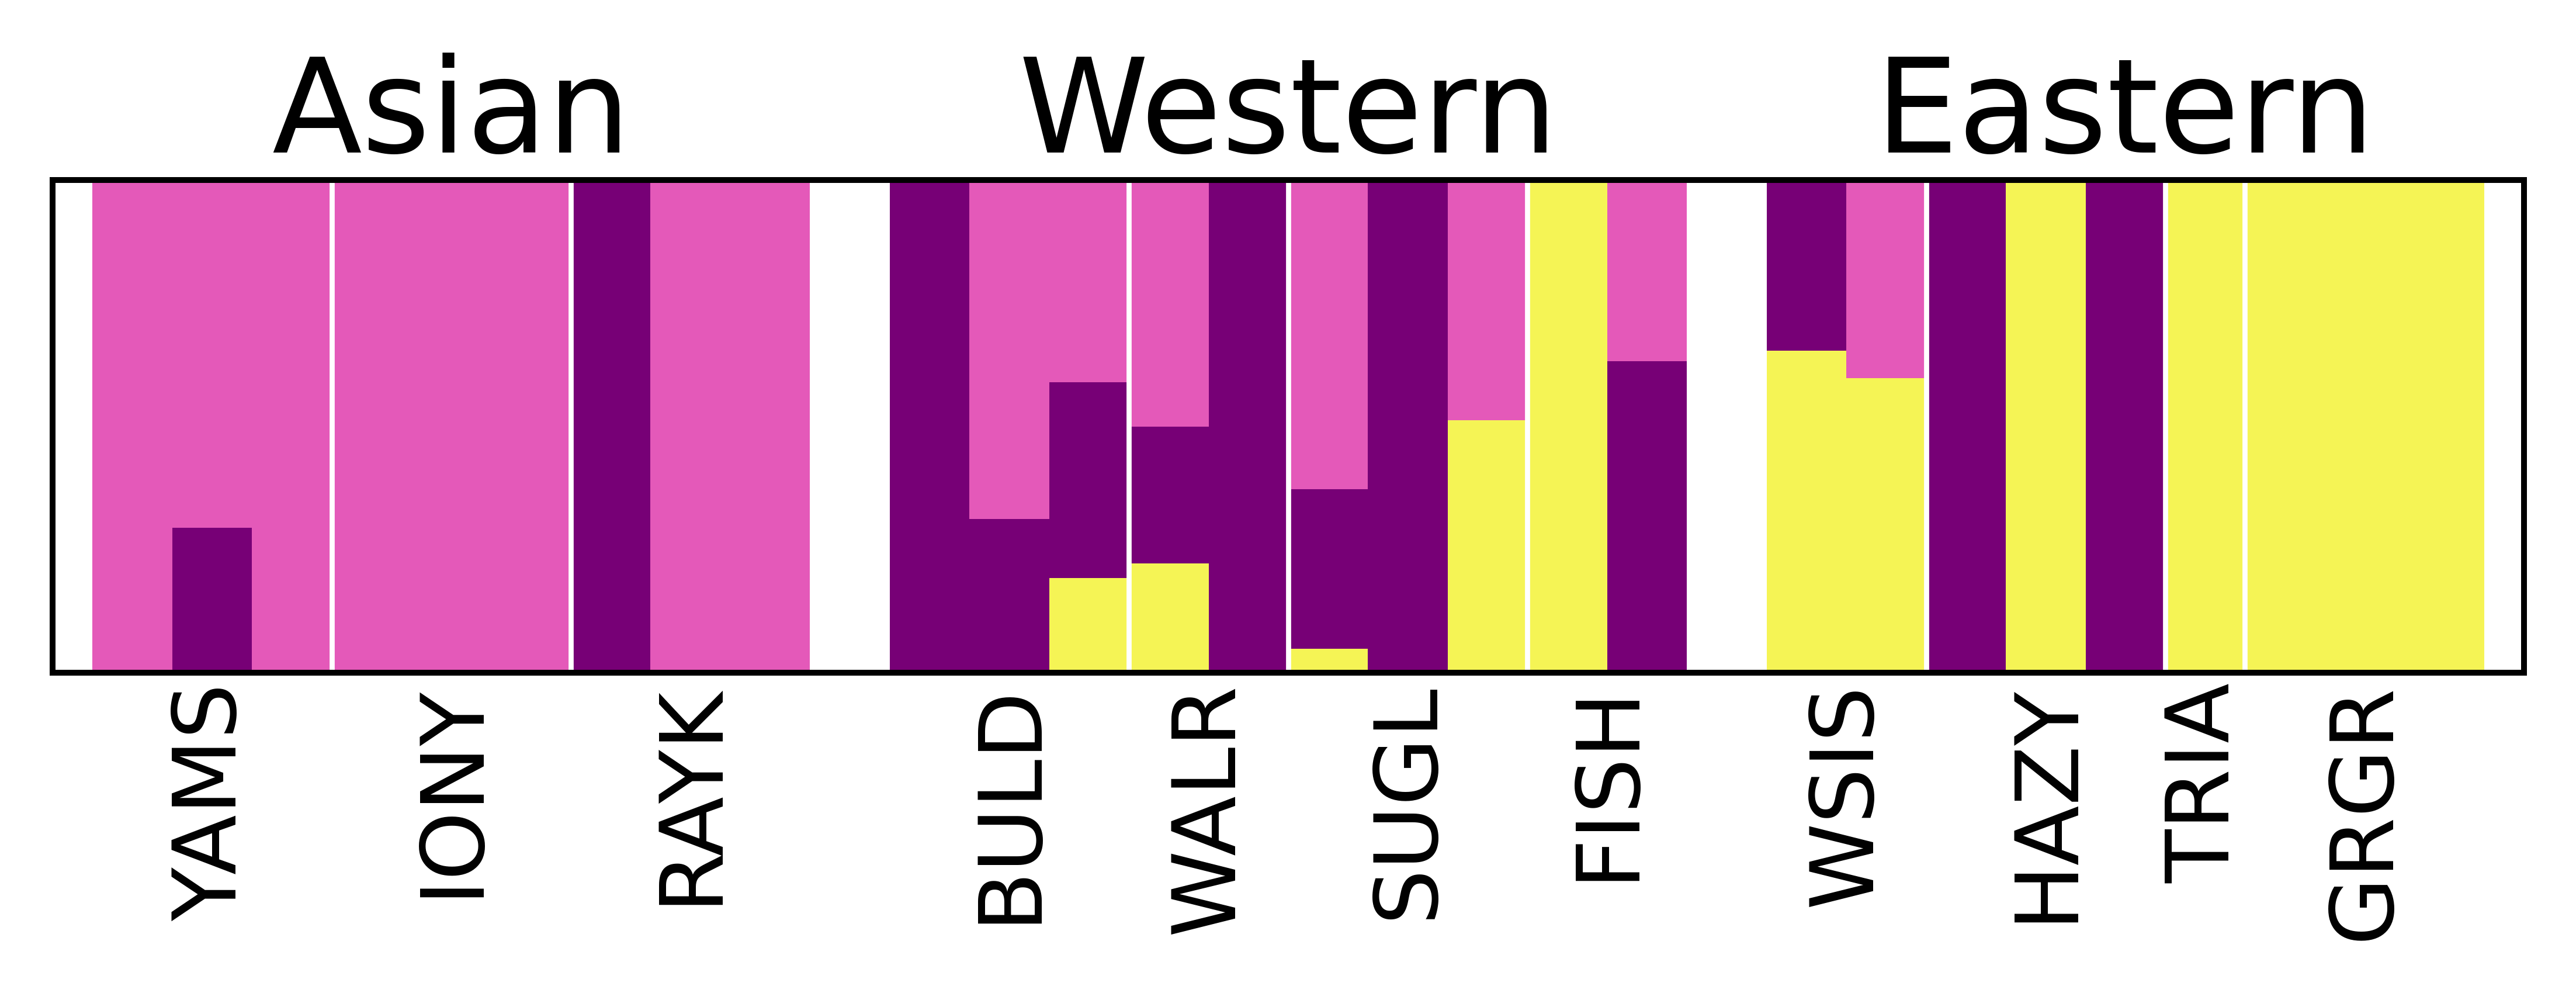

In [ ]:
# baseline X
get_main_admixture(species="GSL", chr="CM019819.2", k=2, figsize=(5, 2))
get_main_admixture(species="SSL", chr="CM019819.2", k=3, figsize=(5, 2))

## TEST 2.1 Effect of autosomes reduction to a single representative

In [ ]:
PALETTE = {
    "SSL_K3": ["#f5f455", "#770076", "#e459b9"],
    "GSL_K3": ["#00c6c2", "#11819f",  "#d0d3fb"],
    "GSL_K3_CM019810.2": ["#d0d3fb", "#00c6c2",  "#11819f"],
    "SSL_K2": ["#770076", "#f5f455"],
    "GSL_K2": ["#11819f", "#00c6c2"],
}
ORDER = {
    "SSL": pop_order_SSL,
    "GSL": pop_order_GSL
}

In [ ]:
def get_main_admixture_2_1(species, chr, k, figsize=(5, 2.5)):
    pop_order=ORDER[species]
    palette=PALETTE[f"{species}_K{k}"]
    group_by=f"Stock_K{k}"


    qfile_pattern = f"{basepath}/VARCALL/vcf_MF_AUT_v/{species}*{chr}/ADMIX/{species}*{chr}.*.rn.admixin.{k}.Q"
    famfile_pattern = f"{basepath}/VARCALL/vcf_MF_AUT_v/{species}*{chr}/ADMIX/{species}*{chr}.*.rn.admixin.fam"

    qfile=glob.glob(qfile_pattern)[0]
    famfile=glob.glob(famfile_pattern)[0]

    print(chr, species, k, group_by)
    get_admixture(qfile, famfile,
                order=pop_order, order_by="Population", x_labels_by="Population", group_by=group_by,
                palette=palette, figsize=figsize)

AUT GSL 2 Stock_K2
AUT SSL 3 Stock_K3


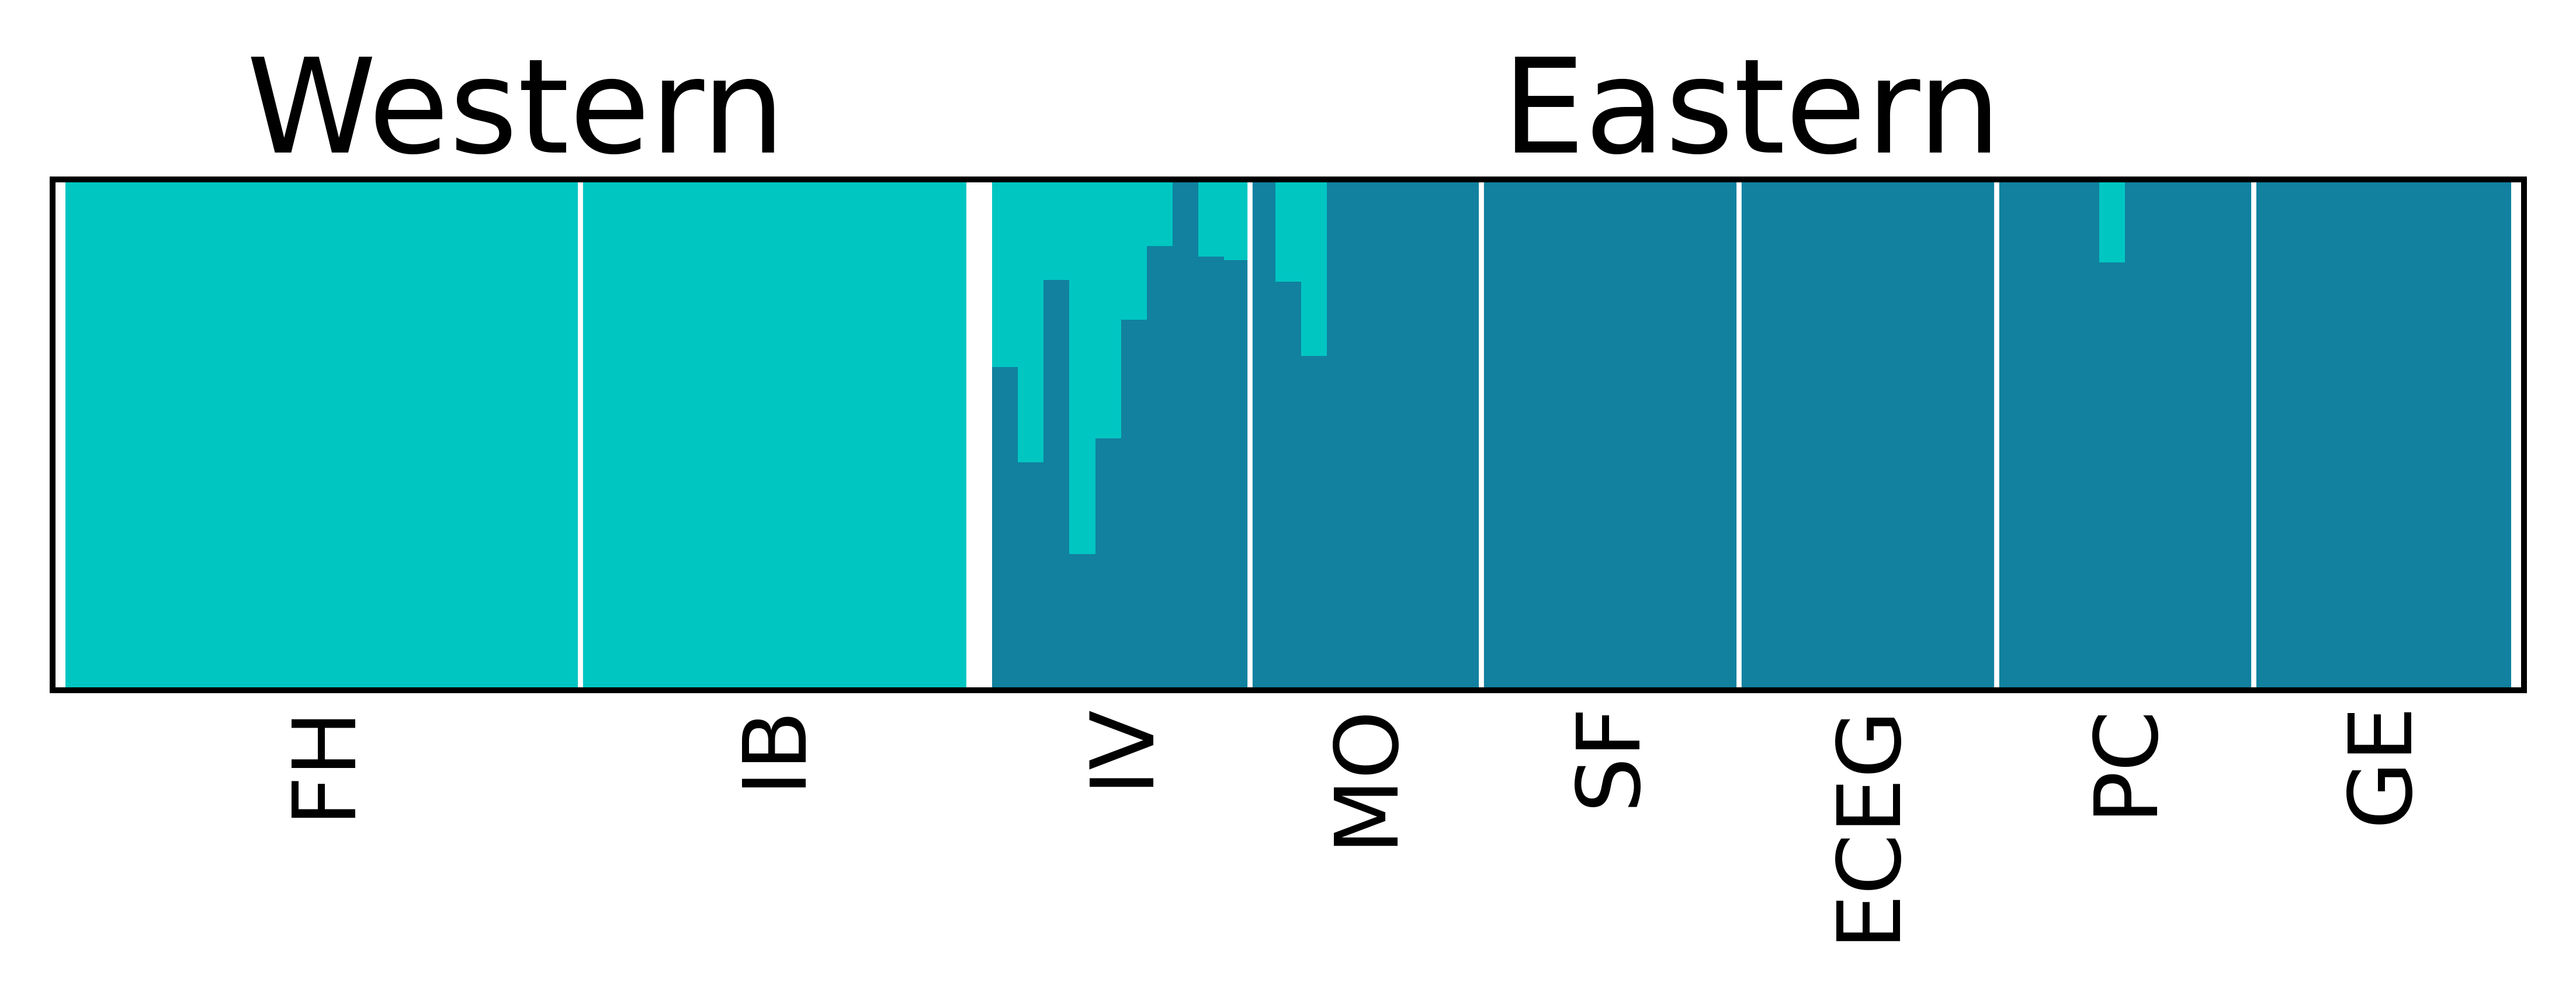

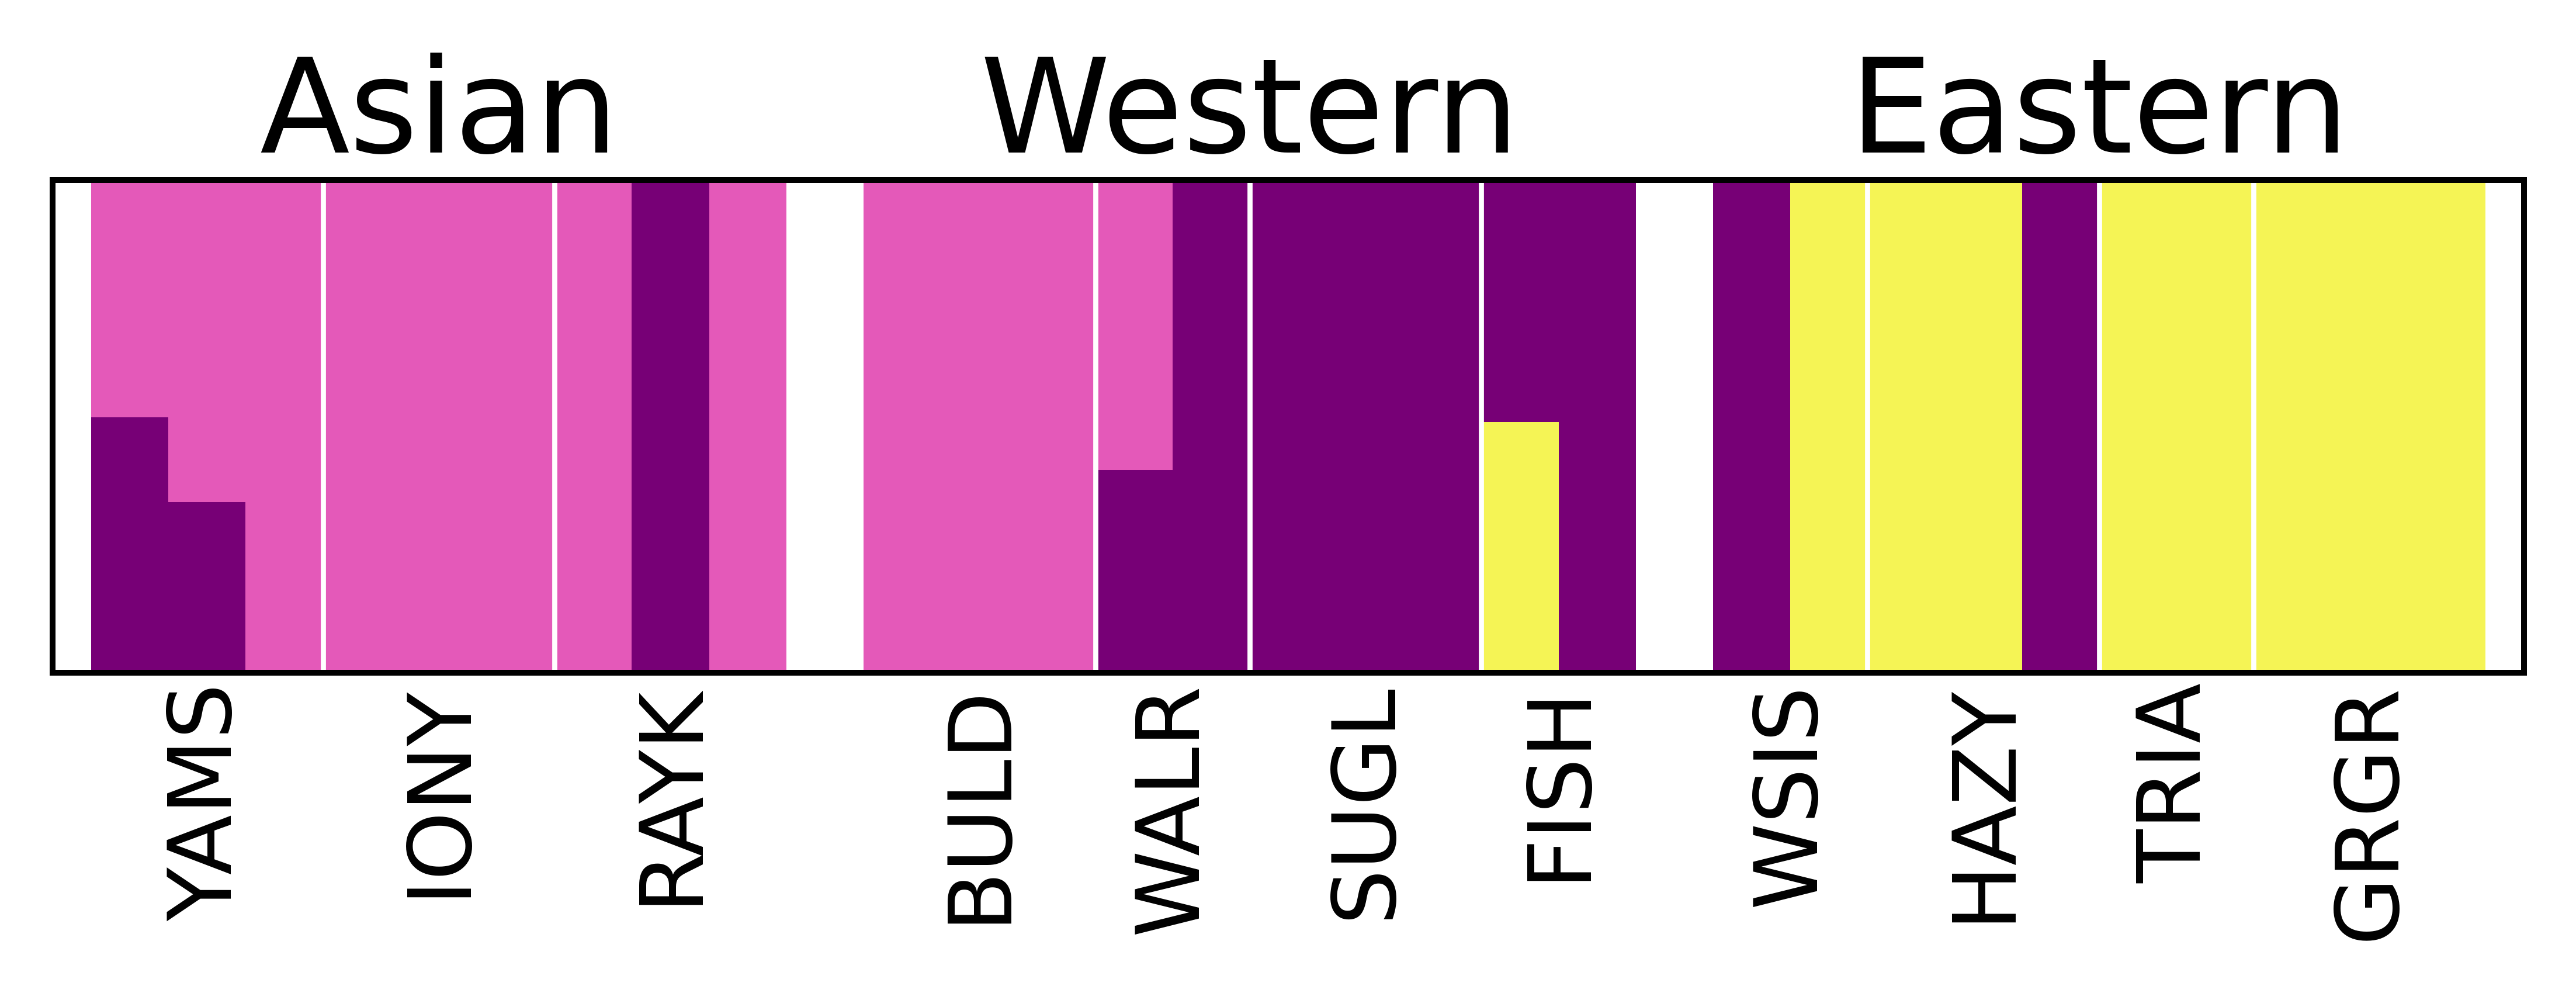

In [119]:
get_main_admixture_2_1(species="GSL", chr="AUT", k=2, figsize=(5, 2))
get_main_admixture_2_1(species="SSL", chr="AUT", k=3, figsize=(5, 2))

##  TEST 2.2 Effect of downsampling chromosome 9

In [ ]:
def get_main_admixture_2_2(species, chr, k, figsize=(5, 2.5)):
    pop_order=ORDER[species]
    palette=PALETTE[f"{species}_K{k}"]
    group_by=f"Stock_K{k}"

    qfile_pattern = f"/dss/dsslegfs01/pr53da/pr53da-dss-0019/projects/2024__SexBias_GeneFlow/Autosomes/resutls/downsamp_chr9/ADMIX/{species}_*{k}.Q"
    famfile_pattern = f"/dss/dsslegfs01/pr53da/pr53da-dss-0019/projects/2024__SexBias_GeneFlow/Autosomes/resutls/downsamp_chr9/ADMIX/{species}_*.fam"

    qfile=glob.glob(qfile_pattern)[0]
    famfile=glob.glob(famfile_pattern)[0]

    print(chr, species, k, group_by)
    get_admixture(qfile, famfile,
                order=pop_order, order_by="Population", x_labels_by="Population", group_by=group_by,
                palette=palette, figsize=figsize)

CM019810.2 GSL 2 Stock_K2
CM019810.2 SSL 3 Stock_K3


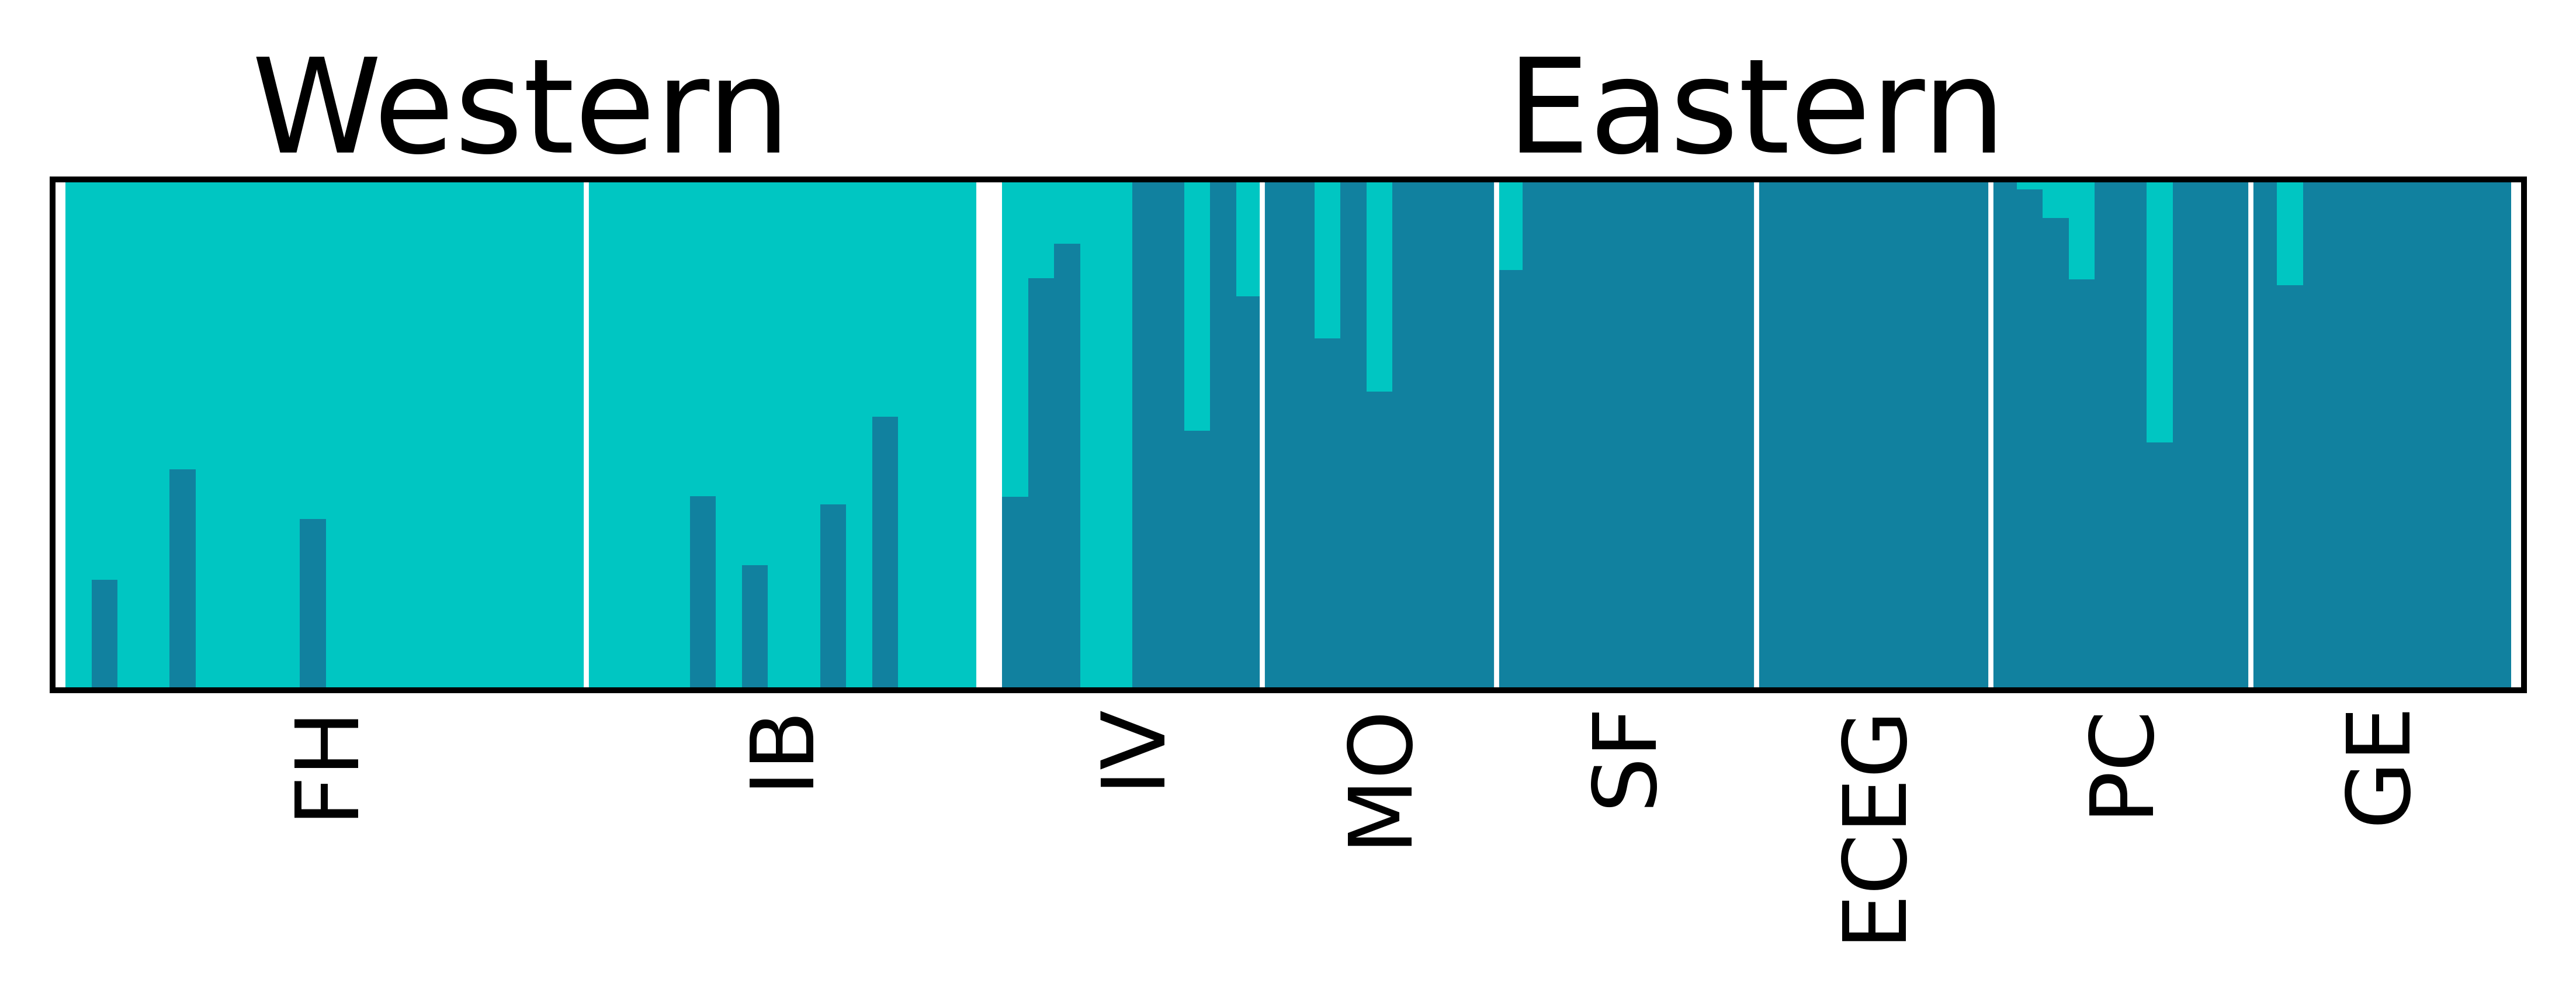

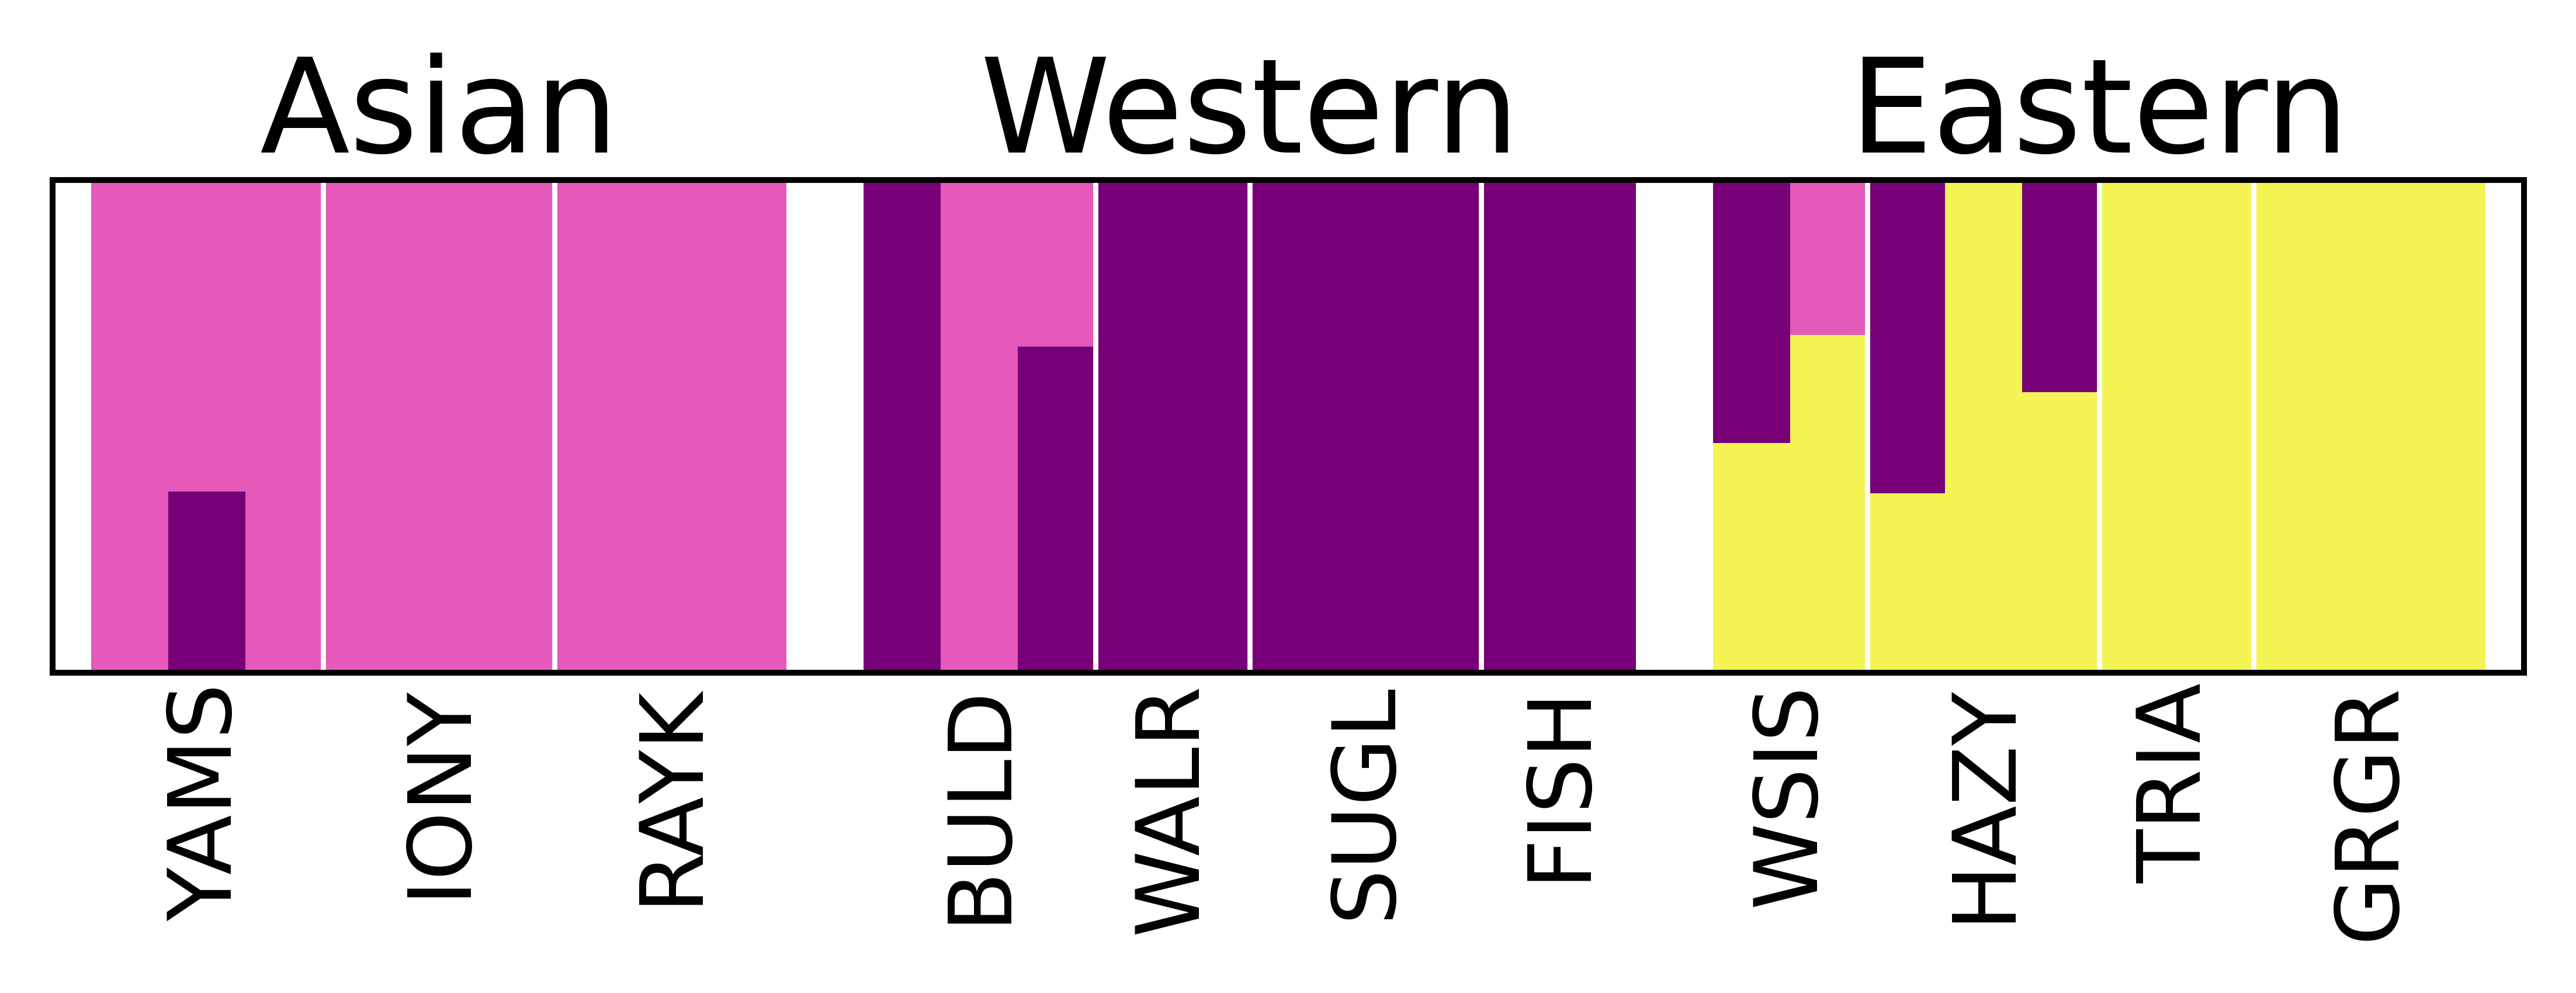

In [94]:
# downsampled
get_main_admixture_2_2(species="GSL", chr="CM019810.2", k=2, figsize=(5, 2))
get_main_admixture_2_2(species="SSL", chr="CM019810.2", k=3, figsize=(5, 2))

## TEST 2.3 Effect of pseudohaploidisation

In [109]:
PALETTE_2_3 = {
    "SSL_K3": ["#770076", "#f5f455", "#e459b9"],
    "GSL_K3": ["#00c6c2", "#11819f",  "#d0d3fb"],
    "SSL_K3_CM019810.2": ["#e459b9", "#770076", "#f5f455"],
    "SSL_K2": ["#770076", "#f5f455"],
    "GSL_K2": ["#11819f", "#00c6c2"],
}
ORDER_2_3 = {
    "SSL": pop_order_SSL,
    "GSL": pop_order_GSL
}

In [105]:
def get_main_admixture_2_3(species, chr, k, figsize=(5, 2.5), chr_lbl="chr9"):
    pop_order=ORDER_2_3[species]
    if species=="SSL" and chr=="CM019810.2" and k==3:
        palette=PALETTE_2_3[f"{species}_K{k}_{chr}"]
    else:
        palette=PALETTE_2_3[f"{species}_K{k}"]
    group_by=f"Stock_K{k}"

    qfile_pattern = f"/dss/dsslegfs01/pr53da/pr53da-dss-0019/projects/2024__SexBias_GeneFlow/Autosomes/data/angsd/ADMIX/02_angsd_{chr_lbl}__{species}-*{k}.Q"
    famfile_pattern = f"/dss/dsslegfs01/pr53da/pr53da-dss-0019/projects/2024__SexBias_GeneFlow/Autosomes/data/angsd/ADMIX/02_angsd_{chr_lbl}__{species}-*.fam"

    qfile=glob.glob(qfile_pattern)[0]
    famfile=glob.glob(famfile_pattern)[0]

    print(chr, species, k, group_by)
    get_admixture(qfile, famfile,
                order=pop_order, order_by="Population", x_labels_by="Population", group_by=group_by,
                palette=palette, figsize=figsize)

CM019810.2 GSL 2 Stock_K2
CM019810.2 SSL 3 Stock_K3


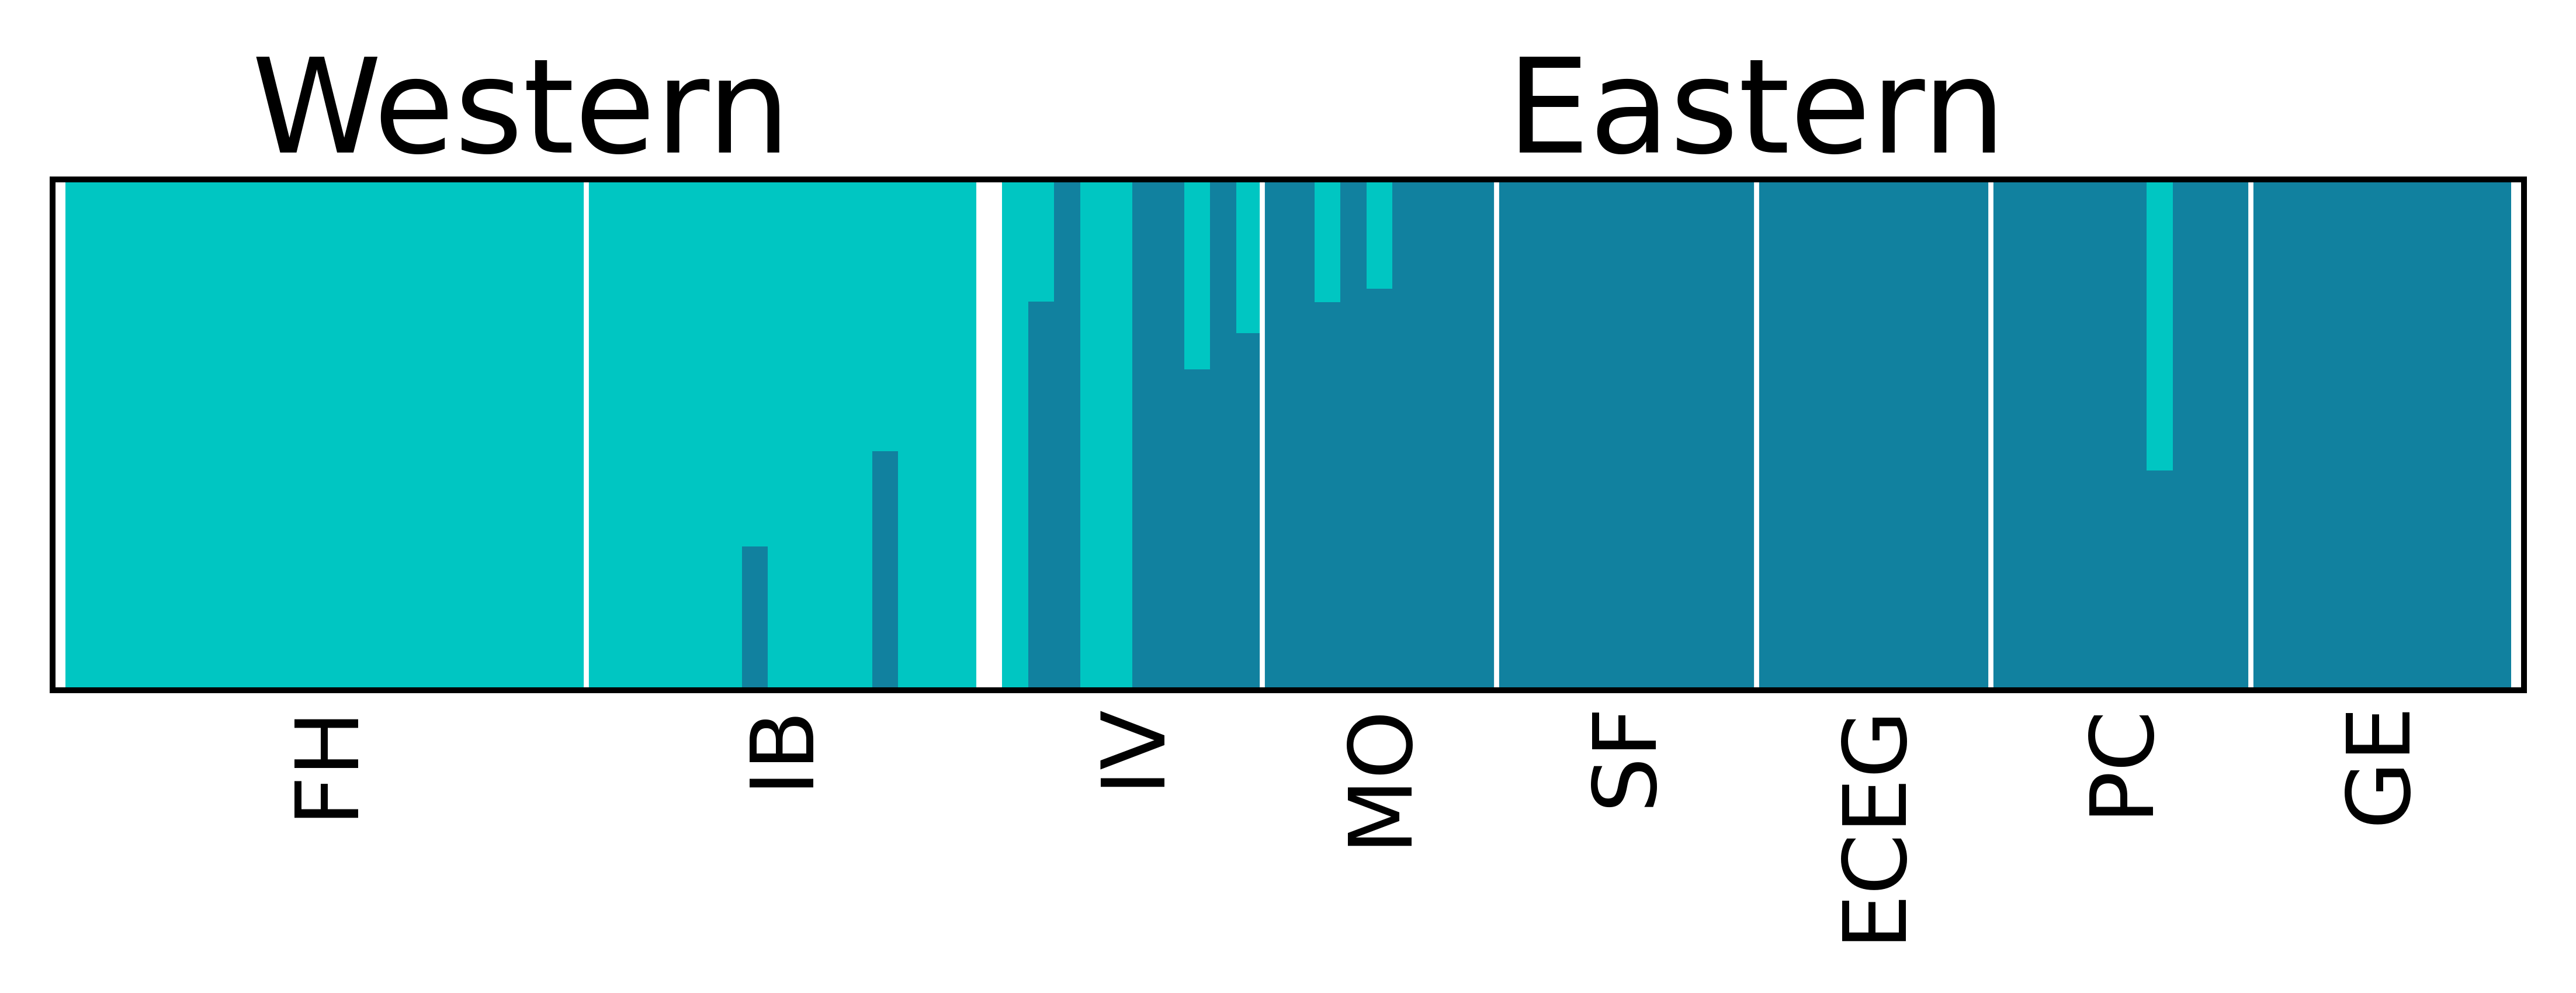

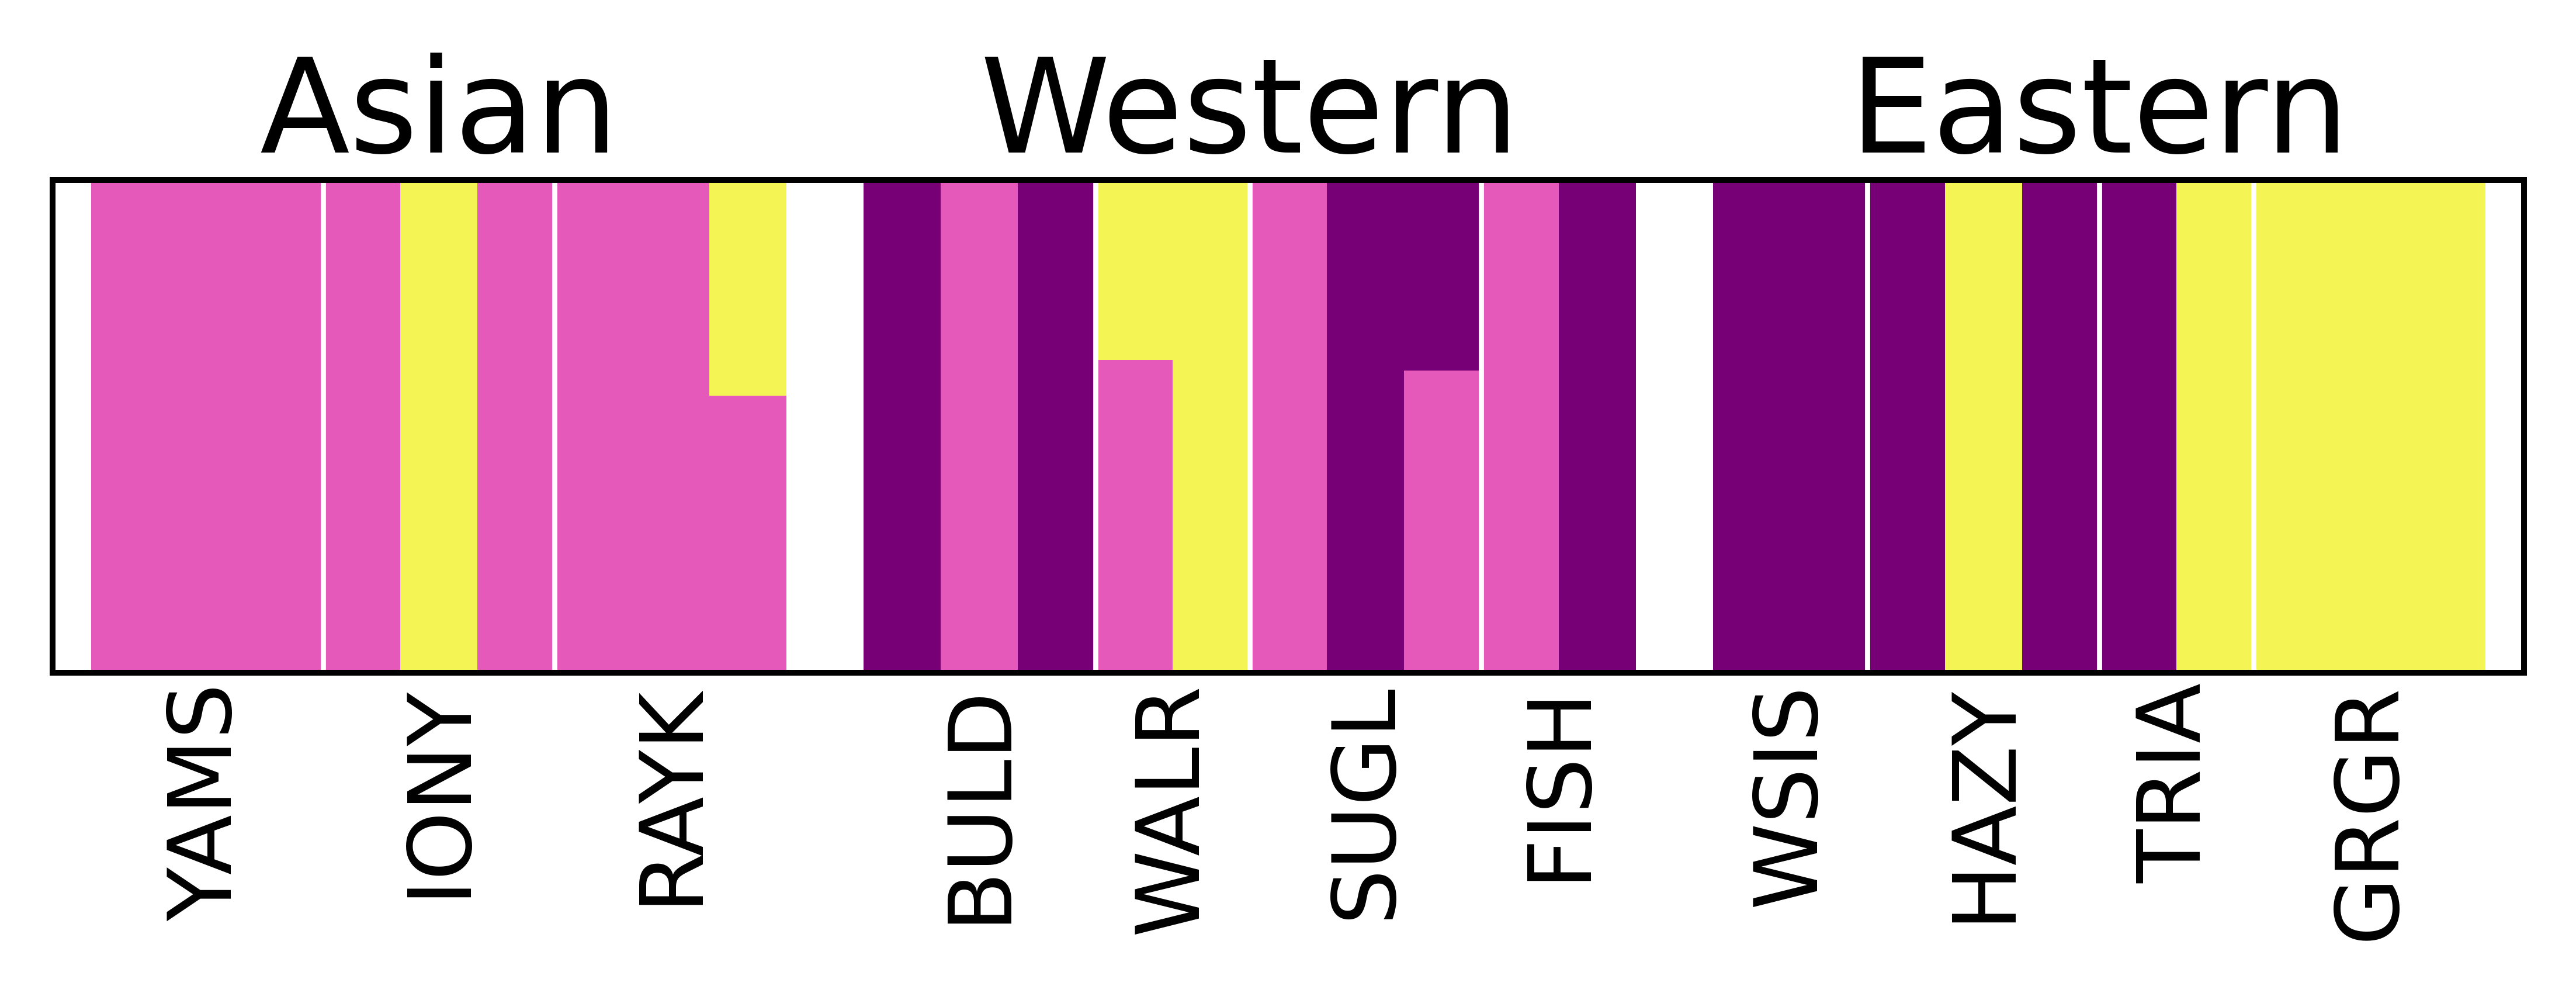

In [106]:
# pseudohaploidisation, chr9
get_main_admixture_2_3(species="GSL", chr="CM019810.2", k=2, figsize=(5, 2), chr_lbl="chr9")
get_main_admixture_2_3(species="SSL", chr="CM019810.2", k=3, figsize=(5, 2), chr_lbl="chr9")

CM019819.2 GSL 2 Stock_K2
CM019819.2 SSL 3 Stock_K3


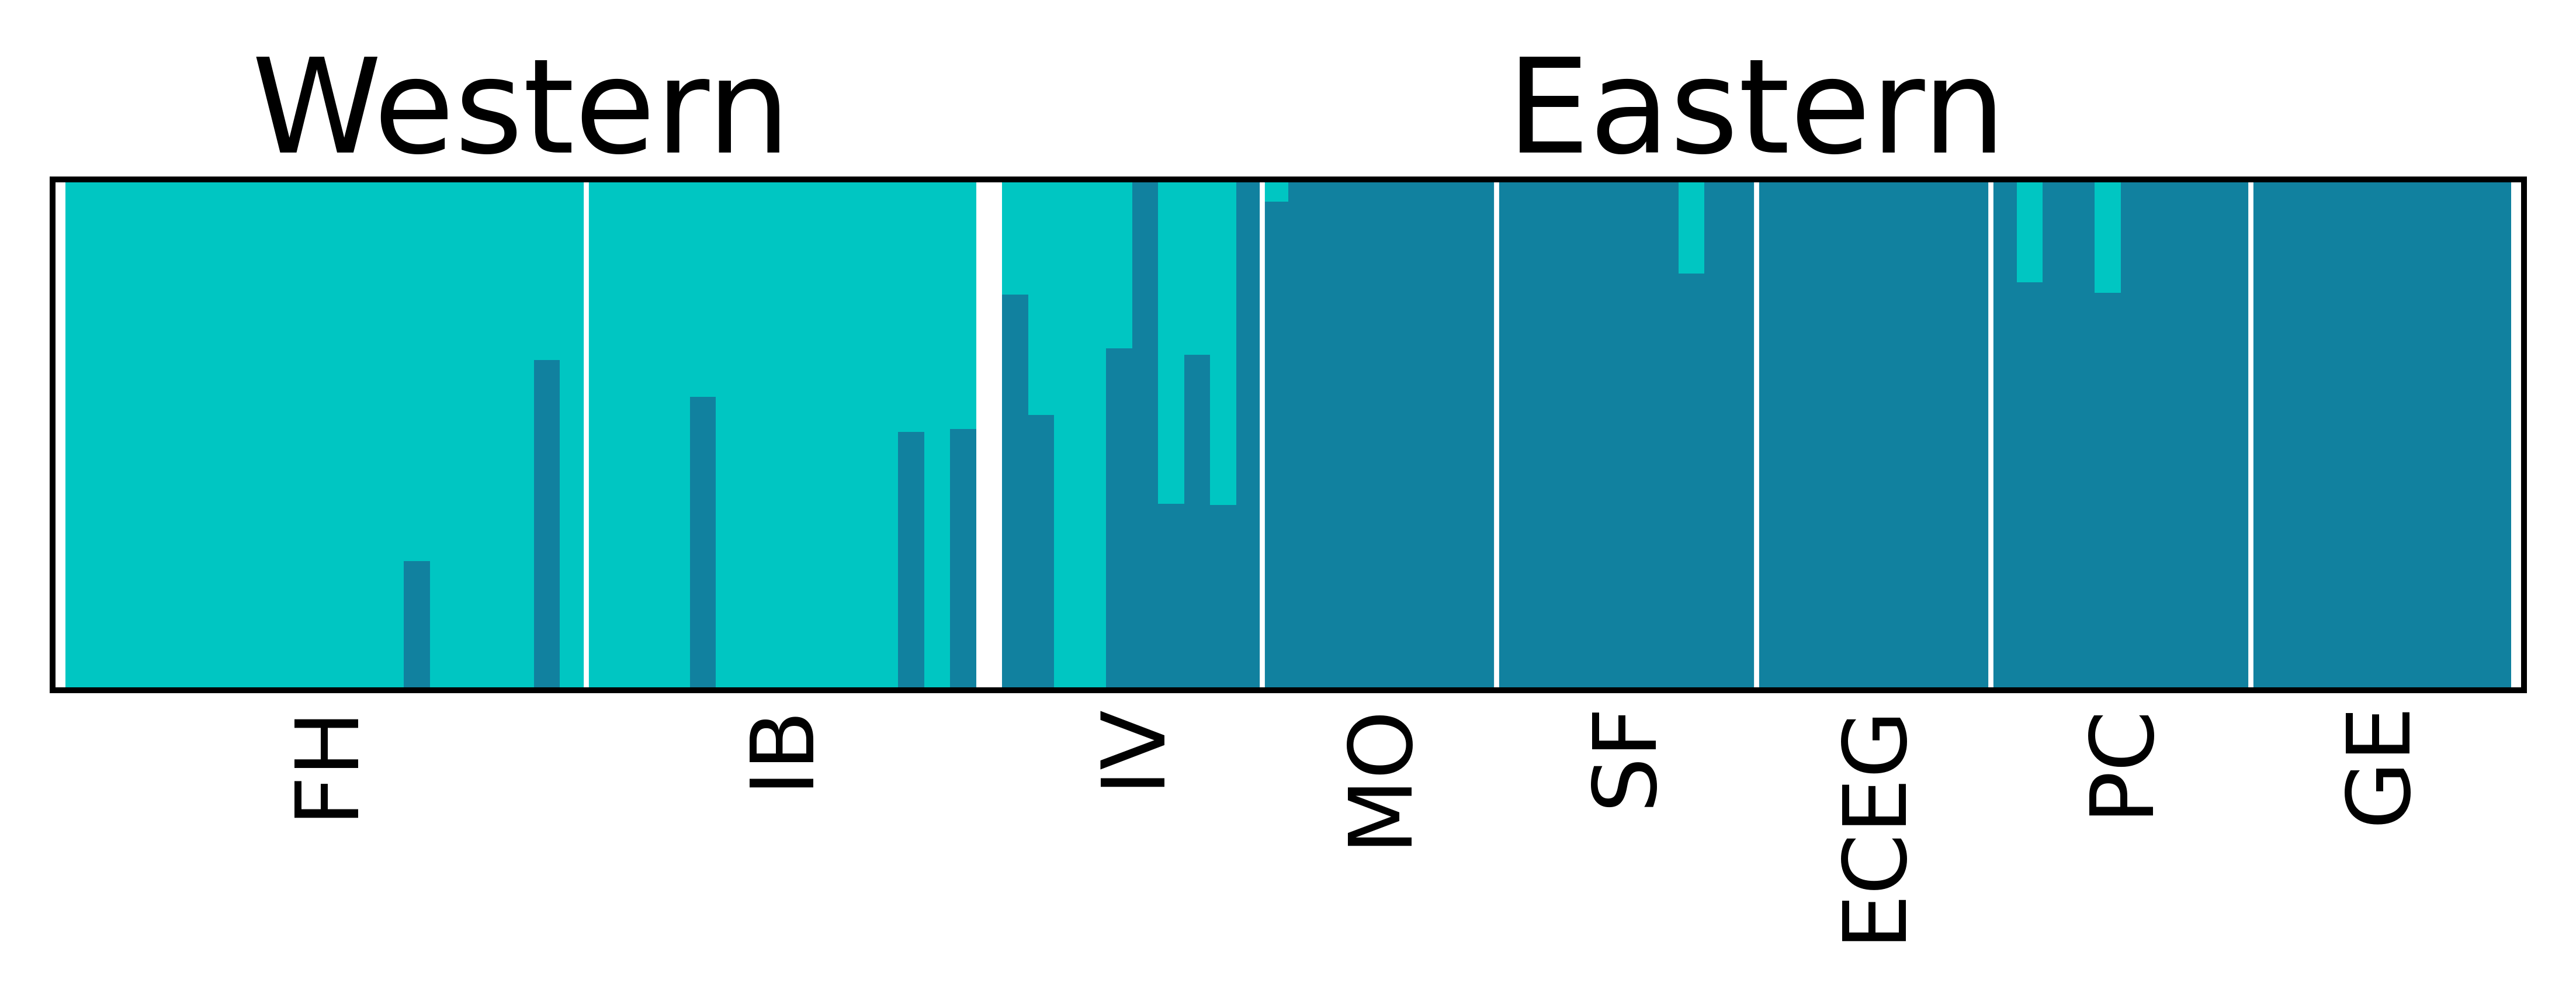

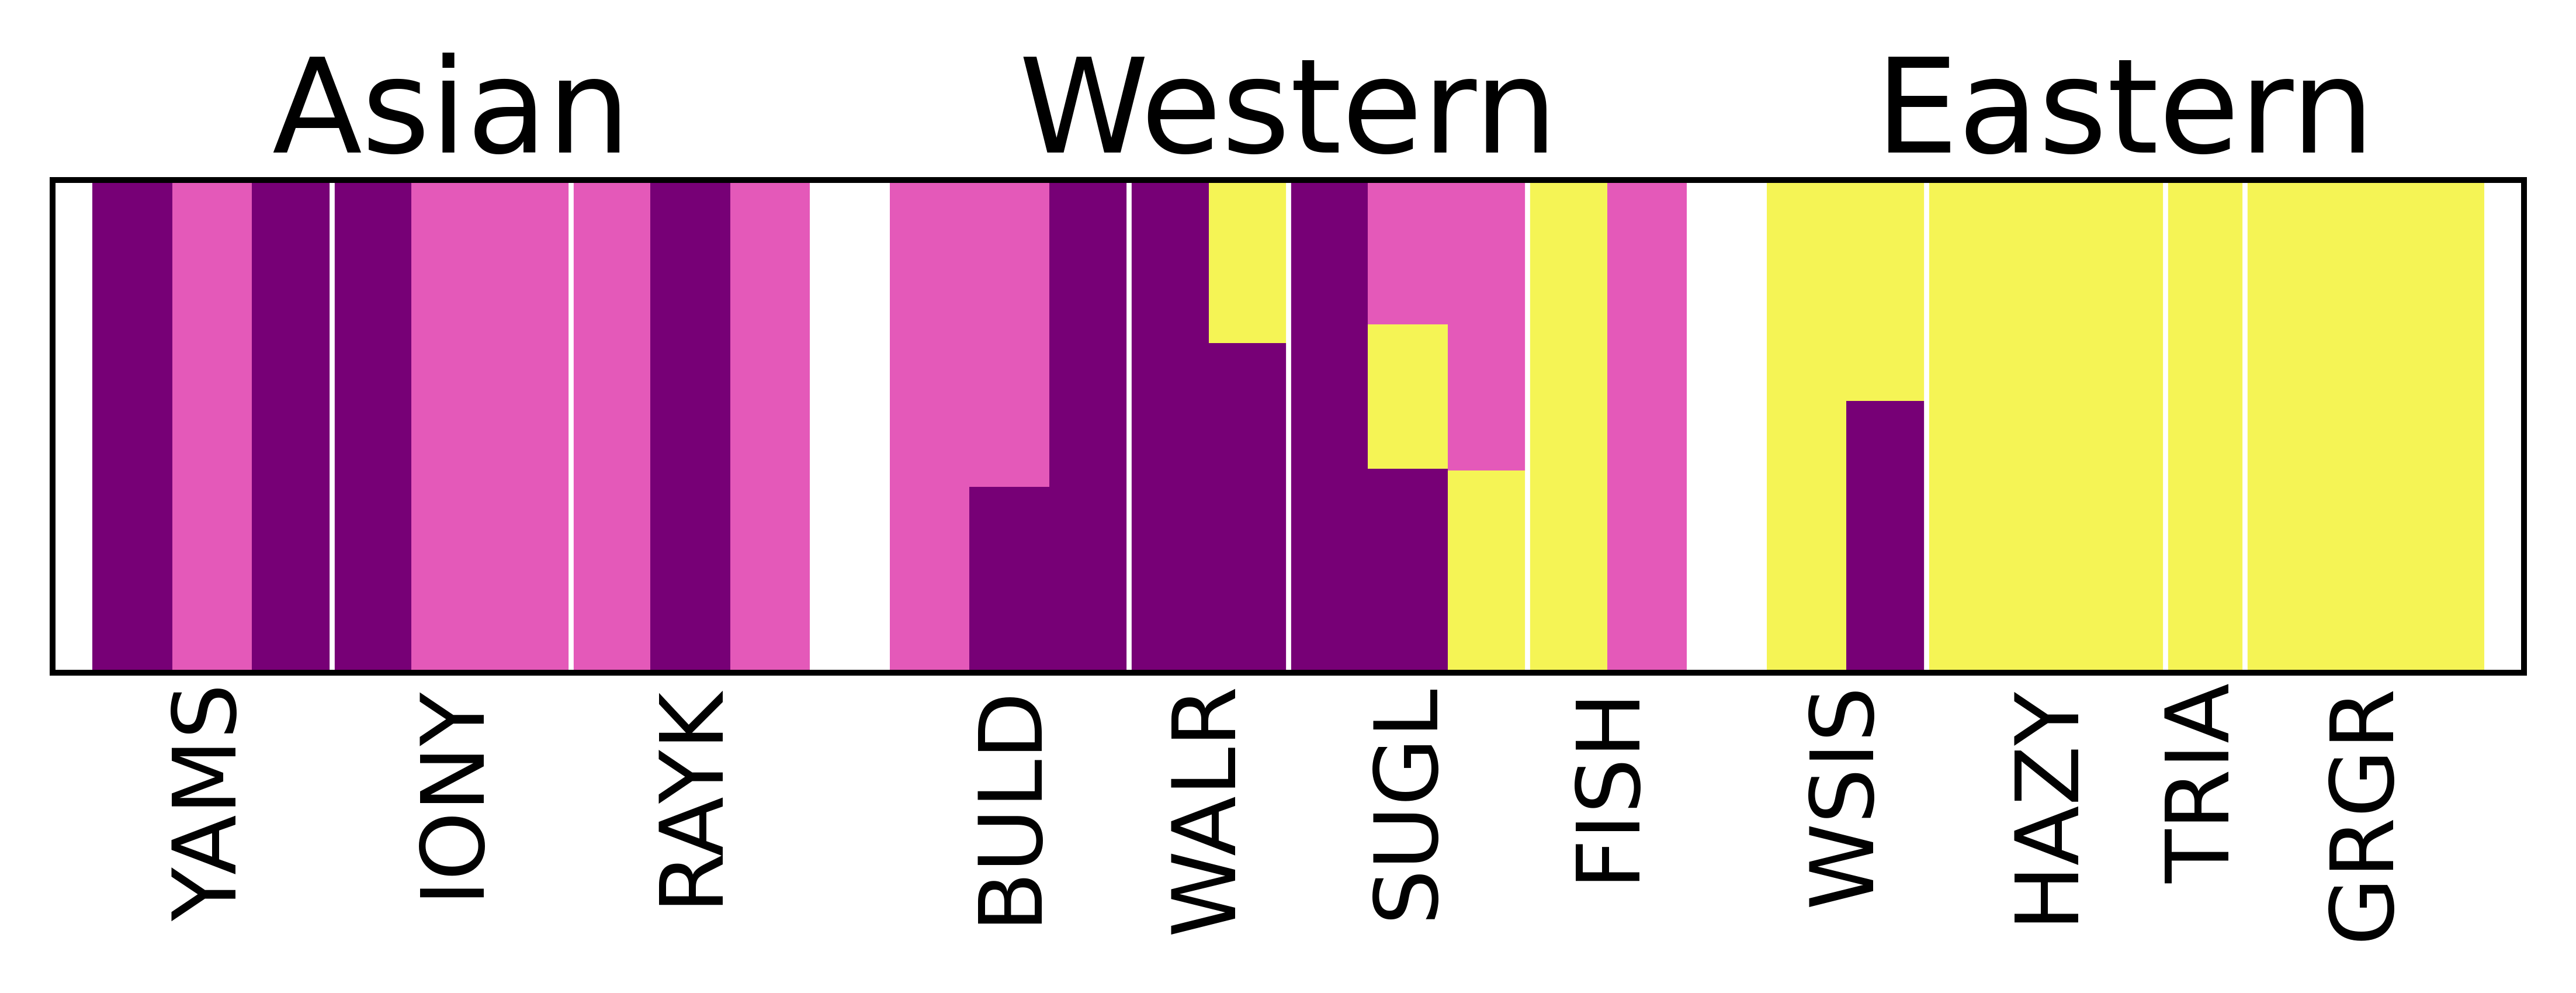

In [111]:
# pseudohaploidisation, X
get_main_admixture_2_3(species="GSL", chr="CM019819.2", k=2, figsize=(5, 2), chr_lbl="Xchr")
get_main_admixture_2_3(species="SSL", chr="CM019819.2", k=3, figsize=(5, 2), chr_lbl="Xchr")